#Problem Statement
---
Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

- Demographics (city, age, gender etc.)
- Tenure information (joining date, Last Date)
- Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

#Import Libraries

In [54]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    auc,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [61]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
sns.set_palette("deep")

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.6 MB/s eta 0:00:00


In [3]:
import optuna

#Utility Func

In [4]:
def plot_feature_importance(model, X, top_n=None):

    # get importance values
    importance = model.feature_importances_

    # create dataframe
    feat_imp = pd.DataFrame({
        "feature": X.columns,
        "importance": importance
    })

    # sort
    feat_imp = feat_imp.sort_values("importance", ascending=False)

    if top_n:
        feat_imp = feat_imp.head(top_n)

    # plot
    plt.figure(figsize=(8,6))

    sns.barplot(
        data=feat_imp,
        x="importance",
        y="feature",
        color=sns.color_palette("deep")[0]
    )

    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

    return feat_imp

In [5]:
def evaluate_classifier(
    y_true,
    y_pred,
    y_prob=None,
    target_recall=0.85,
    show_plots=True
):
    """
    Full classification evaluation.

    For churn problems the threshold is chosen
    to achieve high recall (default 85%).

    Usage:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    evaluate_classifier(y_test, y_pred, y_prob)
    """

    # -----------------------------
    # Confusion Matrix values
    # -----------------------------
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    tpr = tp / (tp + fn) if (tp + fn) else 0
    tnr = tn / (tn + fp) if (tn + fp) else 0
    fpr_val = fp / (fp + tn) if (fp + tn) else 0
    fnr = fn / (fn + tp) if (fn + tp) else 0

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall (TPR)": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "TPR": tpr,
        "TNR": tnr,
        "FPR": fpr_val,
        "FNR": fnr,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
    }

    print("\nClassification Report (Default Threshold = 0.5)\n")
    print(classification_report(y_true, y_pred))

    # -----------------------------
    # ROC Metrics
    # -----------------------------
    if y_prob is not None:

        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)

        fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)

    # -----------------------------
    # Confusion + ROC Plot
    # -----------------------------
    if show_plots:

        if y_prob is not None:

            fig, axes = plt.subplots(1, 2, figsize=(12,5))

            ConfusionMatrixDisplay.from_predictions(
                y_true,
                y_pred,
                ax=axes[0]
            )

            axes[0].set_title("Confusion Matrix (0.5 Threshold)")

            axes[1].plot(fpr_curve, tpr_curve)
            axes[1].plot([0,1],[0,1], linestyle="--")

            axes[1].set_xlabel("False Positive Rate")
            axes[1].set_ylabel("True Positive Rate")
            axes[1].set_title("ROC Curve")

            plt.tight_layout()
            plt.show()

        else:

            ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
            plt.title("Confusion Matrix")
            plt.show()

    # -----------------------------
    # Precision Recall Analysis
    # -----------------------------
    if y_prob is not None:

        pr_precision, pr_recall, thresholds = precision_recall_curve(
            y_true,
            y_prob
        )

        metrics["pr_auc"] = auc(pr_recall, pr_precision)

        # ---------------------------------
        # Recall-based threshold selection
        # ---------------------------------

        idx_candidates = np.where(pr_recall >= target_recall)[0]

        if len(idx_candidates) > 0:

            idx = idx_candidates[-1]

            best_threshold = thresholds[idx]

        else:

            idx = np.argmax(pr_recall[:-1])
            best_threshold = thresholds[idx]

        metrics["business_threshold"] = best_threshold

        # -----------------------------
        # Predictions using business threshold
        # -----------------------------

        y_pred_business = (y_prob >= best_threshold).astype(int)

        print("\nClassification Report (Business Threshold)\n")

        print(classification_report(y_true, y_pred_business))

        # -----------------------------
        # Plot PR + Threshold curves
        # -----------------------------

        if show_plots:

            fig, axes = plt.subplots(1, 2, figsize=(12,5))

            # PR Curve

            axes[0].plot(pr_recall, pr_precision)

            axes[0].scatter(
                pr_recall[idx],
                pr_precision[idx],
                color="red",
                label=f"thr={best_threshold:.3f}"
            )

            axes[0].set_title("Precision–Recall Curve")
            axes[0].set_xlabel("Recall")
            axes[0].set_ylabel("Precision")
            axes[0].legend()

            # Threshold curve

            axes[1].plot(thresholds, pr_precision[:-1], label="Precision")
            axes[1].plot(thresholds, pr_recall[:-1], label="Recall")

            axes[1].axvline(
                best_threshold,
                color="red",
                linestyle="--",
                label=f"thr={best_threshold:.3f}"
            )

            axes[1].set_title("Precision & Recall vs Threshold")
            axes[1].set_xlabel("Threshold")
            axes[1].set_ylabel("Score")
            axes[1].legend()

            plt.tight_layout()
            plt.show()

    # -----------------------------
    # Print Metrics
    # -----------------------------
    print("\nMetrics\n")

    for k, v in metrics.items():
        print(f"{k}: {v}")

In [6]:
def numerical_columns_distribution_with_stats(df, cols = None):
    """
    Generates and displays histograms, boxplots, and density plots for numerical columns
    in a DataFrame, along with key descriptive statistics.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - cols (list, optional): A list of numerical column names to plot. If None,
                             it defaults to all numerical columns (excluding object, category, datetime dtypes).
    """
    if cols is None:
        cols=df.select_dtypes(exclude=['object', 'category', 'datetime']).columns
    for col in cols:

      data = df[col].dropna()

      # Calculate statistics
      mean_val = data.mean()
      median_val = data.median()
      std_val = data.std()
      min_val = data.min()
      max_val = data.max()

      # Print statistics
      print(f"Statistics for {col}:")
      print(f"  Mean   : {mean_val:.2f}")
      print(f"  Median : {median_val:.2f}")
      print(f"  Std Dev: {std_val:.2f}")
      print(f"  Min    : {min_val:.2f}")
      print(f"  Max    : {max_val:.2f}")

      plt.figure(figsize=(15, 5))

      # Histogram
      plt.subplot(1, 3, 1)
      #plt.hist(data, bins=30, color='skyblue', edgecolor='black')
      sns.histplot(
        data=df,             # your DataFrame
        x=data,        # column to plot
        bins=30,             # number of bins
        kde=True,            # add kernel density estimate
        color='royalblue',   # bar color
        edgecolor='black',   # edge of bars
        stat='density'       # normalize histogram to density (optional)
        )
      plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
      plt.axvline(median_val, color='green', linestyle='--', label=f"Median: {median_val:.2f}")
      plt.title(f"Histogram of {col}")
      plt.xlabel(f"{col} Amount")
      plt.ylabel("Frequency")
      plt.legend()

      # Boxplot
      plt.subplot(1, 3, 2)
      sns.boxplot(x=data, color='orange')
      plt.title(f"Boxplot of {col}")
      plt.xlabel(f"{col} Amount")
      plt.text(mean_val, 0.02, f"Mean: {mean_val:.2f}", ha='center', color='red')
      plt.text(median_val, -0.05, f"Median: {median_val:.2f}", ha='center', color='green')

      # Density plot
      plt.subplot(1, 3, 3)
      sns.kdeplot(data, fill=True, color='green')
      plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}")
      plt.axvline(median_val, color='blue', linestyle='--', label=f"Median: {median_val:.2f}")
      plt.title(f"Density Plot of {col}")
      plt.xlabel(f"{col} Amount")
      plt.legend()

      plt.tight_layout()
      plt.show()

#Load Dataset

In [7]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv')

##Column Profiling

- MMMM-YY : Reporting Date (Monthly)
- Driver_ID : Unique id for drivers
- Age : Age of the driver
- Gender : Gender of the driver – Male : 0, Female: 1
- City : City Code of the driver
- Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
- Income : Monthly average Income of the driver
- Date Of Joining : Joining date for the driver
- LastWorkingDate : Last date of working for the driver
- Joining Designation : Designation of the driver at the time of joining
- Grade : Grade of the driver at the time of reporting
- Total Business Value : The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments)
- Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

#Analysis

In [8]:
df.shape, df.size

((19104, 14), 267456)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [10]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [11]:
df.sample(5)

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
926,926,01/01/19,133,44.0,1.0,C23,2,46858,30/07/18,NaN,1,1,329610,2
17263,17263,10/01/19,2544,32.0,0.0,C22,0,67667,28/07/19,22/10/19,2,2,0,1
3667,3667,09/01/20,544,43.0,0.0,C14,2,50345,23/07/15,25/09/20,1,2,0,2
7049,7049,10/01/20,1051,34.0,1.0,C5,2,77483,30/04/16,NaN,1,2,644500,3
14711,14711,03/01/19,2190,28.0,0.0,C7,1,62955,25/04/16,17/03/19,1,2,0,1


In [12]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,19104.0,9551.500000,5.514994e+03,0.0,4775.75,9551.5,14327.25,19103.0
Driver_ID,19104.0,1415.591133,8.107053e+02,1.0,710.00,1417.0,2137.00,2788.0
Age,19043.0,34.668435,6.257912e+00,21.0,30.00,34.0,39.00,58.0
Gender,19052.0,0.418749,4.933670e-01,0.0,0.00,0.0,1.00,1.0
Education_Level,19104.0,1.021671,8.001671e-01,0.0,0.00,1.0,2.00,2.0
Income,19104.0,65652.025126,3.091452e+04,10747.0,42383.00,60087.0,83969.00,188418.0
Joining Designation,19104.0,1.690536,8.369837e-01,1.0,1.00,1.0,2.00,5.0
Grade,19104.0,2.252670,1.026512e+00,1.0,1.00,2.0,3.00,5.0
Total Business Value,19104.0,571662.074958,1.128312e+06,-6000000.0,0.00,250000.0,699700.00,33747720.0
Quarterly Rating,19104.0,2.008899,1.009832e+00,1.0,1.00,2.0,3.00,4.0


In [13]:
df.describe(include='object')

,MMM-YY,City,Dateofjoining,LastWorkingDate
count,19104,19104,19104,1616
unique,24,29,869,493
top,01/01/19,C20,23/07/15,29/07/20
freq,1022,1008,192,70


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isna().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


The dataset contains null values but, this data is at reporting date level so will check wheather null exist after aggregating to driver level. Then will impute null.

In [16]:
df.nunique()

,0
Unnamed: 0,19104
MMM-YY,24
Driver_ID,2381
Age,36
Gender,2
City,29
Education_Level,3
Income,2383
Dateofjoining,869
LastWorkingDate,493


In [17]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [18]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.rename(columns={'MMM-YY': 'Reporting Date (Monthly)'}, inplace=True)

df['Reporting Date (Monthly)'] = pd.to_datetime(df['Reporting Date (Monthly)'], format='%m/%d/%y').dt.to_period('M')
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y')

##LastWorkingDate (it contains our target "Churn")

In [19]:
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y')

Here dataset is at reporting level, so we have to aggregate it to get it to Driver level.

#Aggregating on driver level

In [20]:
agg_map_driver = {
    "Observed_tenure_months" : ("Reporting Date (Monthly)", "count"),
    "Age" : ("Age", "last"),
    "Gender" : ("Gender", "last"),
    "City" : ("City", "last"),
    "Joining Education_Level" : ("Education_Level", "first"),
    "Last Education_Level" : ("Education_Level", "last"),
    "First Income" : ("Income", "first"),
    "Last Income" : ("Income", "last"),
    "Avg. Income" : ("Income", "mean"),
    "Dateofjoining" : ("Dateofjoining", "first"),
    "LastWorkingDate" : ("LastWorkingDate", "max"),
    "Joining Designation" : ("Joining Designation", "first"),
    "Last Designation" : ("Joining Designation", "last"),
    "Joining Grade" : ("Grade", "first"),
    "Last Grade" : ("Grade", "last"),
    "Total Business Value" : ("Total Business Value", "sum"),
    "Avg Business Value" : ("Total Business Value", "mean"),
    "Mean Quarterly Rating" : ("Quarterly Rating", "mean")
}

In [21]:
df_churn = df.groupby('Driver_ID').agg(**agg_map_driver).reset_index()

In [22]:
df_churn['Churn'] = df_churn['LastWorkingDate'].notna().astype(int)

In [23]:
df_churn.sample(10)

,Driver_ID,Observed_tenure_months,Age,Gender,City,Joining Education_Level,Last Education_Level,First Income,Last Income,Avg. Income,Dateofjoining,LastWorkingDate,Joining Designation,Last Designation,Joining Grade,Last Grade,Total Business Value,Avg Business Value,Mean Quarterly Rating,Churn
84,103,8,26.0,1.0,C28,1,1,68913,68913,68913.0,2019-11-30,2020-04-07,2,2,2,2,544380,6.804750e+04,1.000,1
1008,1189,4,26.0,0.0,C19,1,1,15970,15970,15970.0,2020-04-17,2020-07-24,1,1,1,1,0,0.000000e+00,1.000,1
1969,2310,4,31.0,0.0,C6,2,2,23566,23566,23566.0,2019-01-11,2020-02-20,1,1,1,1,0,0.000000e+00,1.000,1
1294,1521,1,31.0,0.0,C20,1,1,31401,31401,31401.0,2020-07-12,NaT,1,1,1,1,0,0.000000e+00,1.000,0
1075,1264,5,27.0,1.0,C19,2,2,77369,77369,77369.0,2016-04-29,2019-02-05,1,1,3,3,1445310,2.890620e+05,1.000,1
1816,2135,5,43.0,1.0,C24,0,0,47426,47426,47426.0,2020-08-14,NaT,3,3,3,3,194150,3.883000e+04,1.000,0
401,471,2,38.0,0.0,C12,0,0,59318,59318,59318.0,2020-08-05,2020-06-27,3,3,3,3,0,0.000000e+00,1.000,1
112,134,3,32.0,0.0,C27,0,0,76904,76904,76904.0,2020-12-10,NaT,3,3,3,3,190550,6.351667e+04,1.000,0
841,990,24,43.0,1.0,C17,1,1,119806,119806,119806.0,2015-06-12,NaT,1,1,4,4,30755460,1.281478e+06,2.375,0
1795,2113,2,32.0,1.0,C15,1,1,38992,38992,38992.0,2019-09-13,2019-11-10,1,1,1,1,0,0.000000e+00,1.000,1


In [24]:
df_churn.shape

(2381, 20)

In [26]:
df_churn.duplicated().sum()

np.int64(0)

In [25]:
df_churn.isna().sum()

,0
Driver_ID,0
Observed_tenure_months,0
Age,0
Gender,0
City,0
Joining Education_Level,0
Last Education_Level,0
First Income,0
Last Income,0
Avg. Income,0


Previously there are many null values in other col than `LastWorkingDate` col which contains our is our target. Those null are just driver forgot to enter those details, so after aggregation all nulls are gone and no imputation is required.

#Feature Engineering

In [27]:
df_churn[df_churn['First Income'] == df_churn['Last Income']]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,68.99059
0,31.00941


Drivers whose income remain unchanged, 69% churned.

In [28]:
df_churn[df_churn['First Income'] < df_churn['Last Income']]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,93.023256
1,6.976744


Drivers whose income increased, only 7% churned.

In [29]:
df_churn[df_churn['First Income'] > df_churn['Last Income']]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,


In [30]:
df_churn["Income_change"] = df_churn["Last Income"] - df_churn["First Income"]

df_churn["Income_growth_rate"] = (
    (df_churn["Last Income"] - df_churn["First Income"]) /
    df_churn["First Income"]
)

In [31]:
np.sum(df_churn['Joining Grade'] != df_churn['Last Grade'])

np.int64(43)

In [32]:
np.sum(df_churn['Joining Grade'] < df_churn['Last Grade'])

np.int64(43)

In [33]:
df_churn[df_churn['Joining Grade'] < df_churn['Last Grade']]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,93.023256
1,6.976744


In [34]:
df_churn[df_churn['Joining Grade'] >= df_churn['Last Grade']]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,68.99059
0,31.00941


In [35]:
df_churn["Grade_change"] = (
    df_churn["Last Grade"] - df_churn["Joining Grade"]
)

In [36]:
df_churn["Promoted"] = (df_churn["Grade_change"] > 0).astype(int)

In [37]:
df_churn["Business_per_month"] = (
    df_churn["Total Business Value"] /
    df_churn["Observed_tenure_months"]
)

In [38]:
df_churn["Income_per_business"] = (
    df_churn["Avg. Income"] /
    (df_churn["Avg Business Value"] + 1)
)

In [39]:
df_churn["Low_rating_flag"] = (
    df_churn["Mean Quarterly Rating"] < 3
).astype(int)

In [40]:
df_churn.groupby('Low_rating_flag')['Churn'].value_counts(normalize=True)*100

Low_rating_flag  Churn
0                0        76.510067
                 1        23.489933
1                1        70.833333
                 0        29.166667
Name: proportion, dtype: float64

In [41]:
df_churn.groupby('Churn')['Low_rating_flag'].value_counts(normalize=True)*100

Churn  Low_rating_flag
0      1                  85.098039
       0                  14.901961
1      1                  97.834158
       0                   2.165842
Name: proportion, dtype: float64

In [42]:
np.sum(df_churn['Joining Education_Level'] != df_churn['Last Education_Level'])

np.int64(0)

In [43]:
np.sum(df_churn['Joining Designation'] != df_churn['Last Designation'])

np.int64(0)

In [44]:
df_churn[df_churn['Avg Business Value'] <= 0]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,77.091907
0,22.908093


In [45]:
df_churn[df_churn['Avg Business Value'] > 0]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,63.801453
0,36.198547


In [46]:
df_churn[df_churn['Total Business Value'] > 0]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,63.801453
0,36.198547


In [47]:
df_churn[df_churn['Total Business Value'] <= 0]['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
1,77.091907
0,22.908093


In [48]:
df_churn.groupby('Churn')['Mean Quarterly Rating'].mean()

,Mean Quarterly Rating
Churn,
0,1.957077
1,1.381316


In [50]:
df_churn.sample(10)

,Driver_ID,Observed_tenure_months,Age,Gender,City,Joining Education_Level,Last Education_Level,First Income,Last Income,Avg. Income,Dateofjoining,LastWorkingDate,Joining Designation,Last Designation,Joining Grade,Last Grade,Total Business Value,Avg Business Value,Mean Quarterly Rating,Churn,Income_change,Income_growth_rate,Grade_change,Promoted,Business_per_month,Income_per_business,Low_rating_flag
1122,1323,7,44.0,1.0,C6,1,1,67140,67140,67140.0,2019-04-08,2020-01-30,1,1,1,1,1752360,2.503371e+05,1.857143,1,0,0.0,0,0,2.503371e+05,0.268197,1
490,570,12,34.0,1.0,C19,2,2,37929,37929,37929.0,2020-06-01,NaT,1,1,1,1,7429260,6.191050e+05,2.750000,0,0,0.0,0,0,6.191050e+05,0.061264,1
1441,1692,2,34.0,0.0,C3,2,2,82666,82666,82666.0,2019-02-08,2019-10-09,3,3,3,3,0,0.000000e+00,1.000000,1,0,0.0,0,0,0.000000e+00,82666.000000,1
1872,2199,10,27.0,0.0,C5,2,2,93170,93170,93170.0,2020-02-27,NaT,3,3,3,3,10752230,1.075223e+06,3.600000,0,0,0.0,0,0,1.075223e+06,0.086652,0
182,213,24,37.0,0.0,C24,0,0,59947,59947,59947.0,2018-05-09,NaT,2,2,2,2,12182590,5.076079e+05,2.250000,0,0,0.0,0,0,5.076079e+05,0.118097,1
67,83,10,34.0,0.0,C23,2,2,115159,115159,115159.0,2019-08-29,2020-07-06,3,3,3,3,750000,7.500000e+04,1.000000,1,0,0.0,0,0,7.500000e+04,1.535433,1
889,1048,4,37.0,1.0,C1,2,2,52668,52668,52668.0,2020-07-17,2020-11-13,2,2,2,2,0,0.000000e+00,1.000000,1,0,0.0,0,0,0.000000e+00,52668.000000,1
1021,1202,4,30.0,1.0,C10,2,2,75735,75735,75735.0,2018-06-15,2019-04-04,2,2,2,2,564380,1.410950e+05,1.000000,1,0,0.0,0,0,1.410950e+05,0.536762,1
2201,2579,4,46.0,0.0,C23,1,1,50326,50326,50326.0,2019-01-15,2019-04-27,2,2,2,2,4266380,1.066595e+06,2.500000,1,0,0.0,0,0,1.066595e+06,0.047184,1
1503,1763,2,22.0,1.0,C12,0,0,33042,33042,33042.0,2019-11-30,2020-01-21,1,1,1,1,0,0.000000e+00,1.000000,1,0,0.0,0,0,0.000000e+00,33042.000000,1


In [56]:
df_churn["Gender"] = df_churn["Gender"].astype(int)

In [57]:
df_churn = df_churn.drop(columns=["Driver_ID","Dateofjoining","LastWorkingDate","Joining Education_Level"])

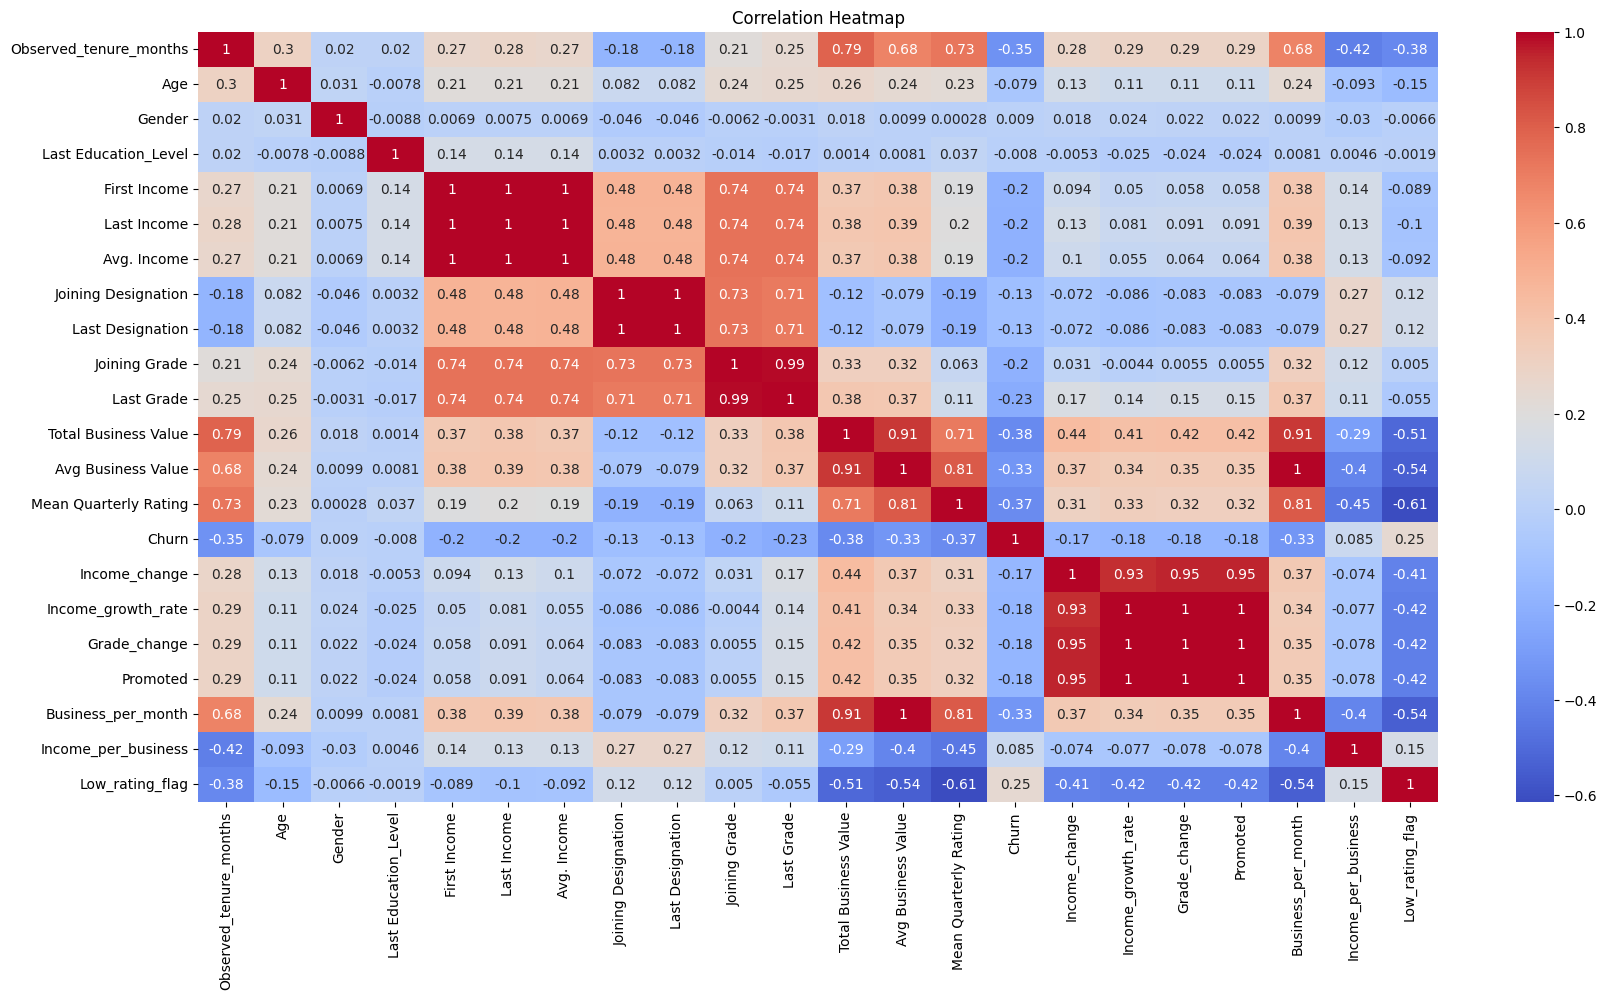

In [58]:
plt.figure(figsize=(20,10))
sns.heatmap(df_churn.select_dtypes(exclude='object').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Removing Highly correlated cols

In [59]:
df_churn = df_churn.drop(columns = ["First Income","Last Income","Promoted", "Avg Business Value", "Last Designation", "Joining Grade", "Income_change", "Grade_change"])

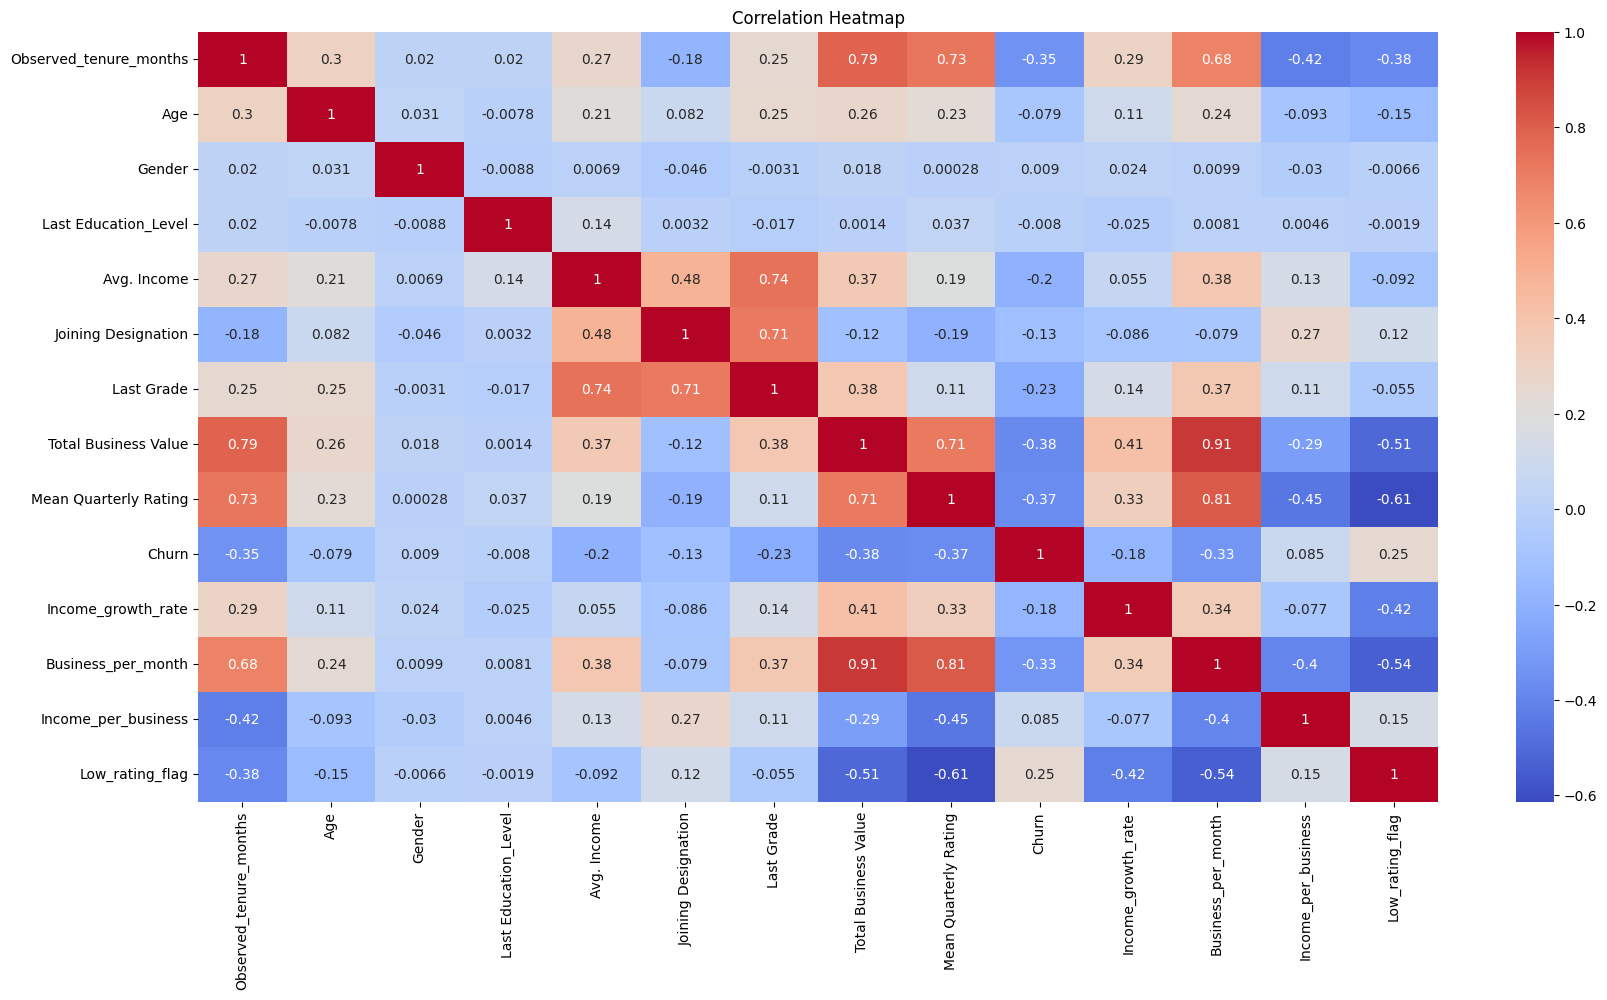

In [60]:
plt.figure(figsize=(20,10))
sns.heatmap(df_churn.select_dtypes(exclude='object').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Statistics for Observed_tenure_months:
  Mean   : 8.02
  Median : 5.00
  Std Dev: 6.78
  Min    : 1.00
  Max    : 24.00


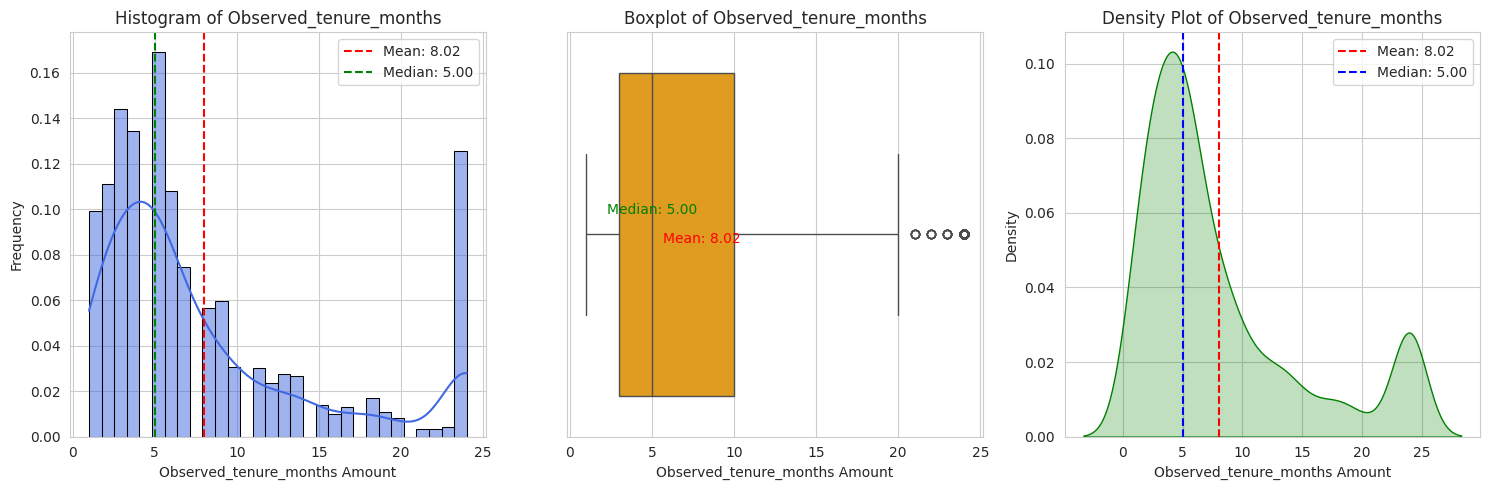

Statistics for Age:
  Mean   : 33.66
  Median : 33.00
  Std Dev: 5.98
  Min    : 21.00
  Max    : 58.00


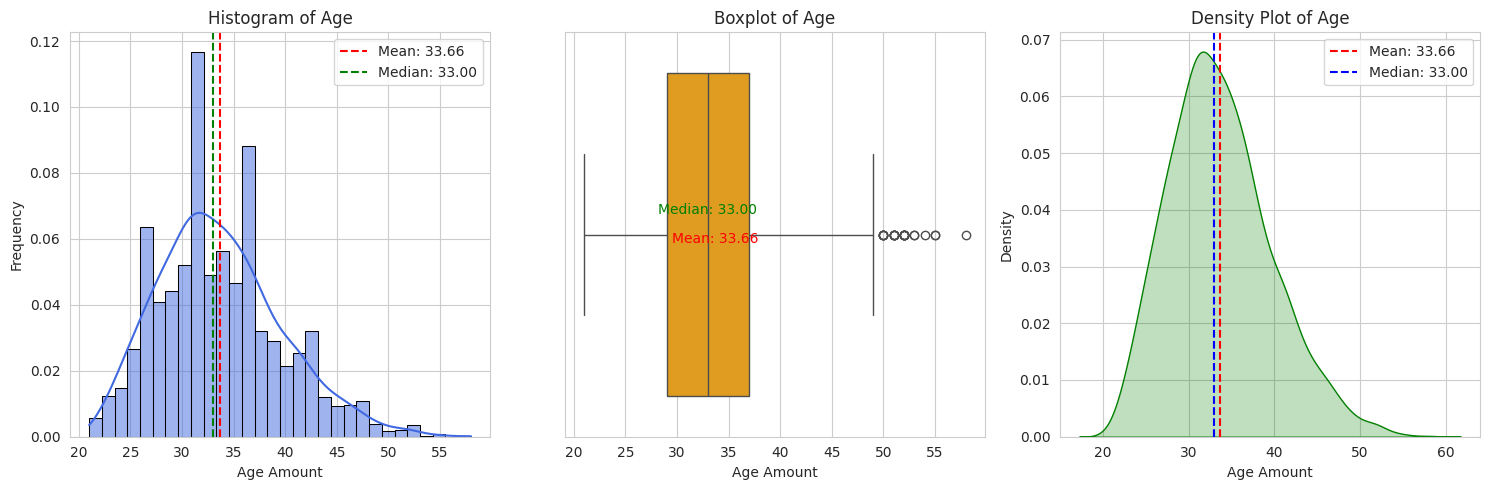

Statistics for Gender:
  Mean   : 0.41
  Median : 0.00
  Std Dev: 0.49
  Min    : 0.00
  Max    : 1.00


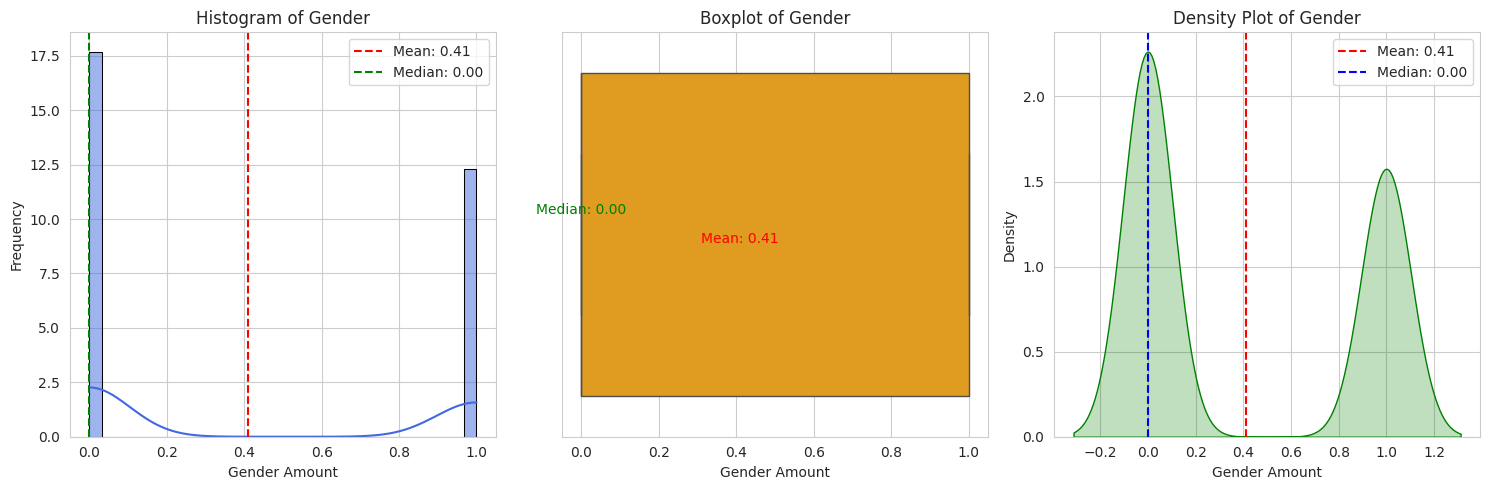

Statistics for Last Education_Level:
  Mean   : 1.01
  Median : 1.00
  Std Dev: 0.82
  Min    : 0.00
  Max    : 2.00


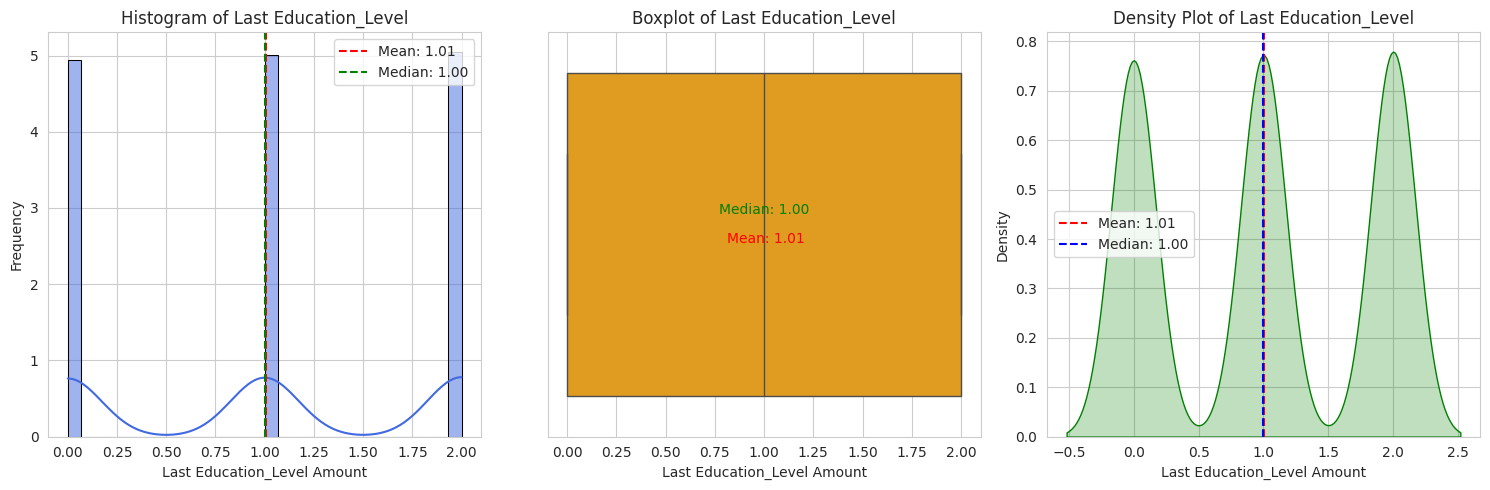

Statistics for Avg. Income:
  Mean   : 59232.46
  Median : 55285.00
  Std Dev: 28298.21
  Min    : 10747.00
  Max    : 188418.00


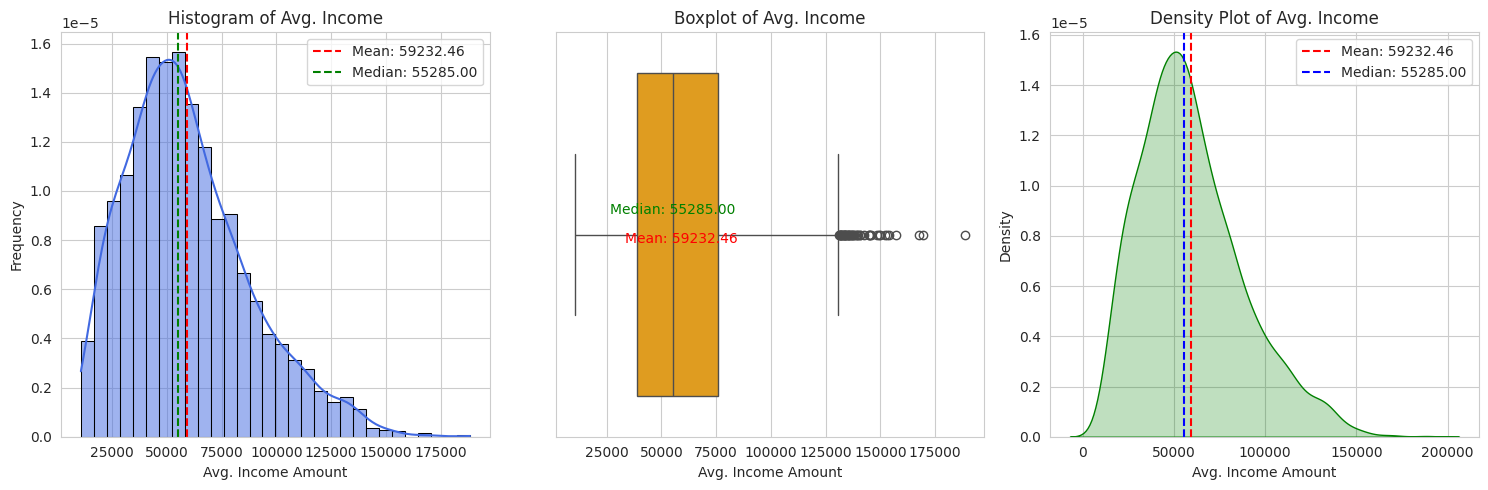

Statistics for Joining Designation:
  Mean   : 1.82
  Median : 2.00
  Std Dev: 0.84
  Min    : 1.00
  Max    : 5.00


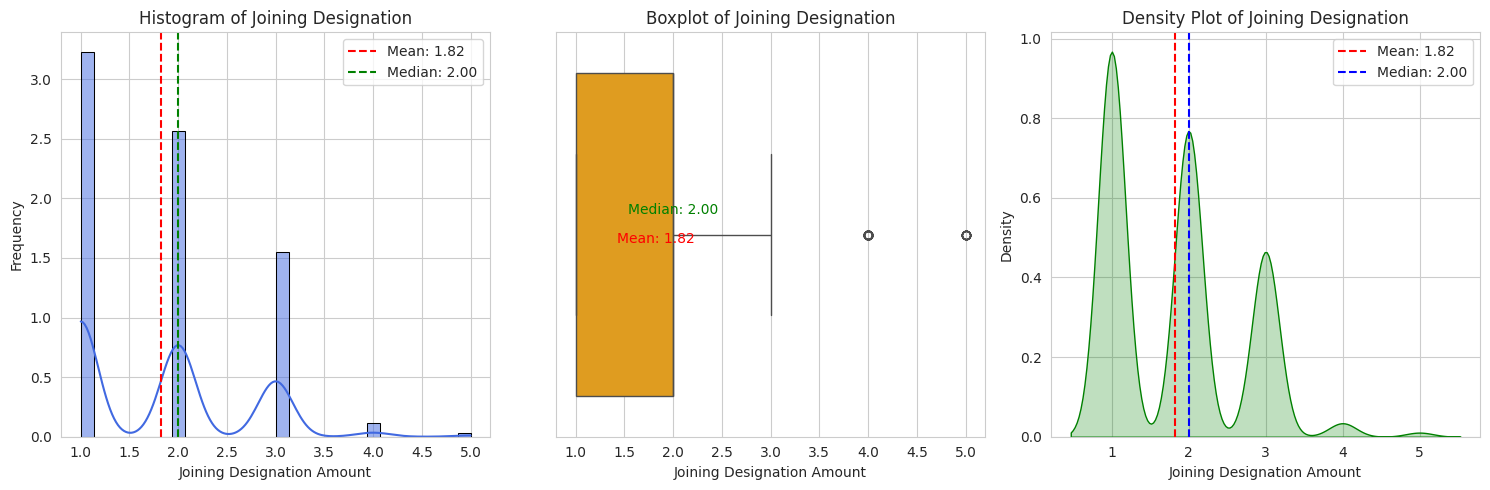

Statistics for Last Grade:
  Mean   : 2.10
  Median : 2.00
  Std Dev: 0.94
  Min    : 1.00
  Max    : 5.00


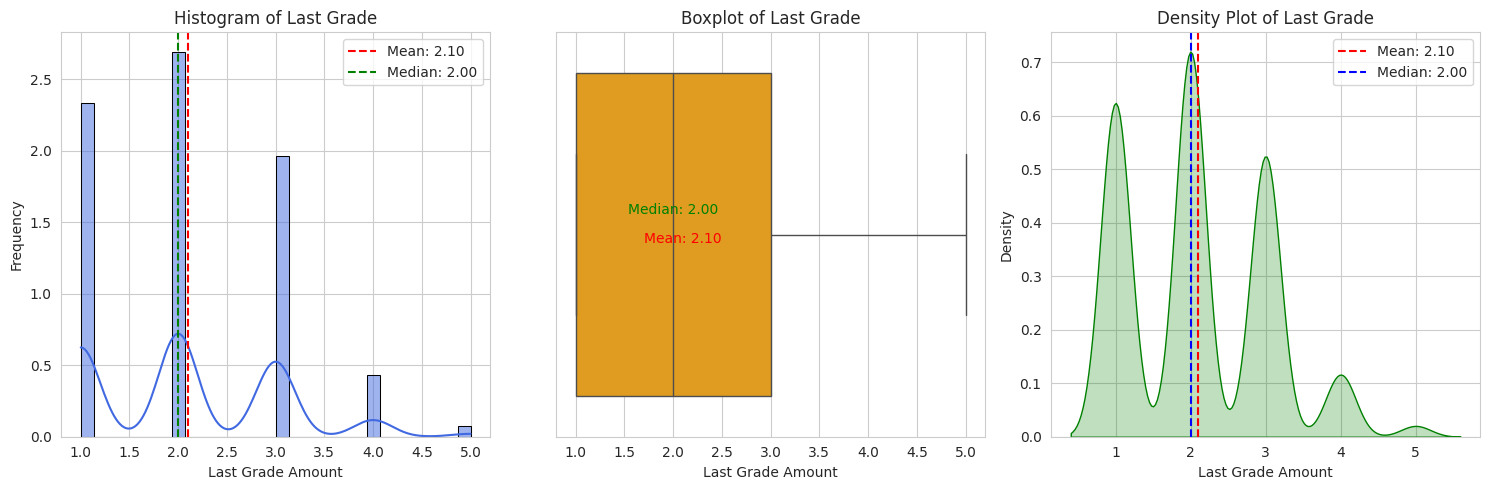

Statistics for Total Business Value:
  Mean   : 4586741.82
  Median : 817680.00
  Std Dev: 9127115.31
  Min    : -1385530.00
  Max    : 95331060.00


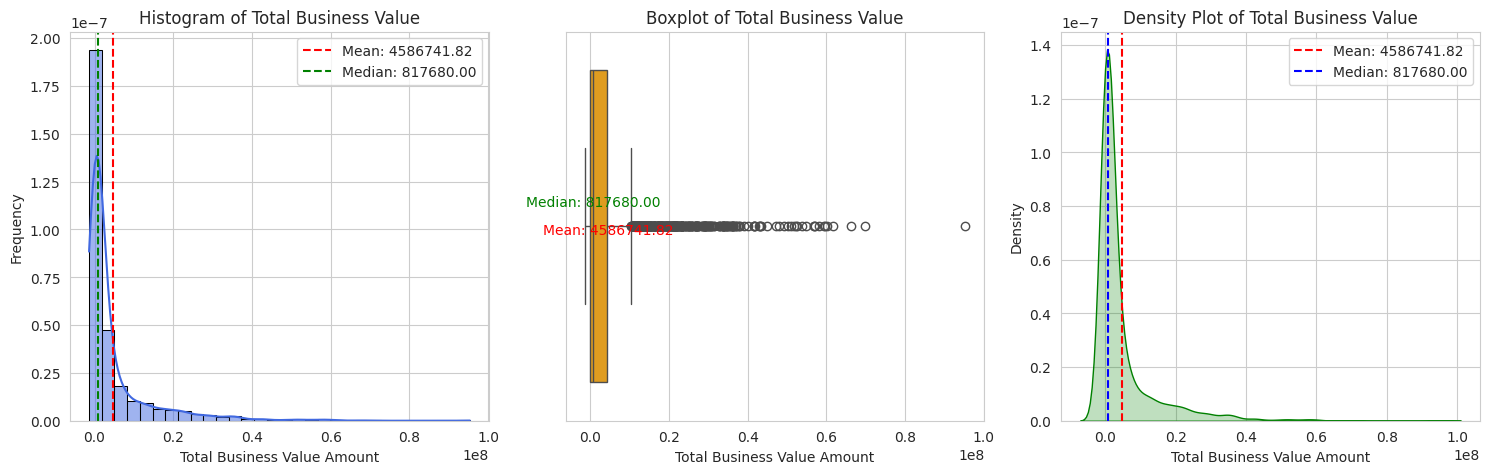

Statistics for Mean Quarterly Rating:
  Mean   : 1.57
  Median : 1.00
  Std Dev: 0.72
  Min    : 1.00
  Max    : 4.00


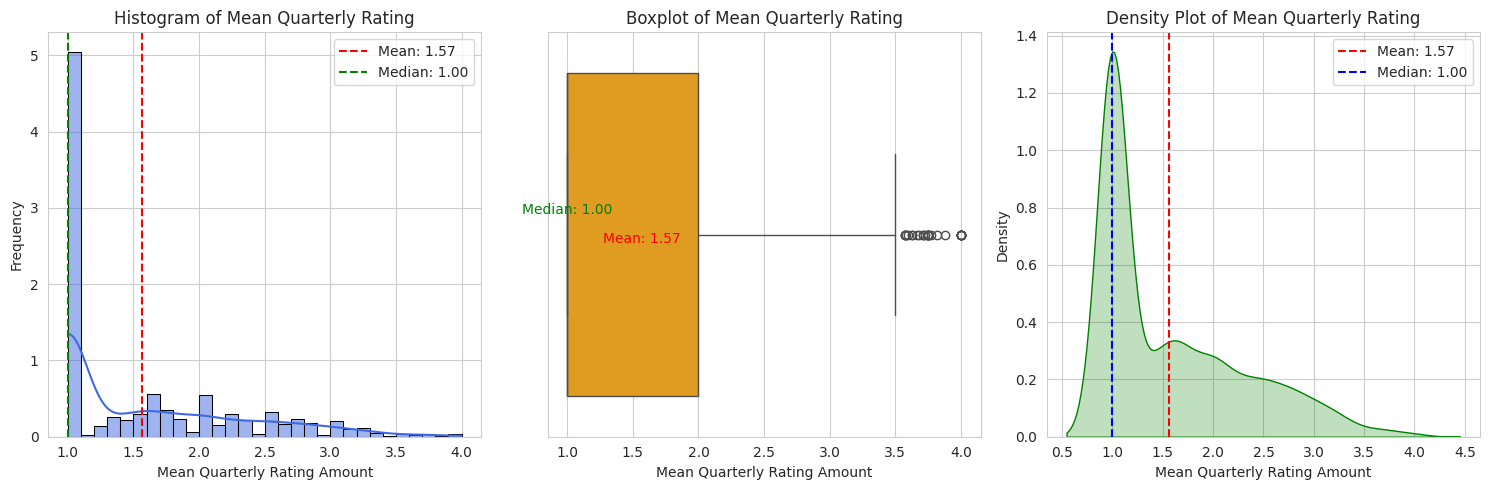

Statistics for Churn:
  Mean   : 0.68
  Median : 1.00
  Std Dev: 0.47
  Min    : 0.00
  Max    : 1.00


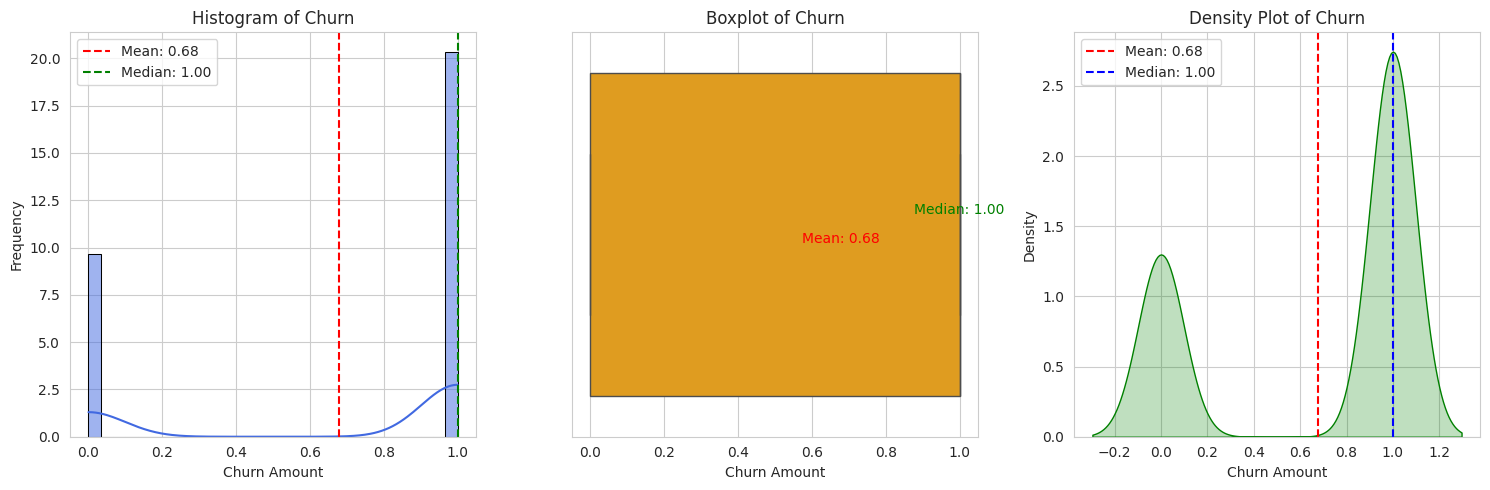

Statistics for Income_growth_rate:
  Mean   : 0.00
  Median : 0.00
  Std Dev: 0.01
  Min    : 0.00
  Max    : 0.11


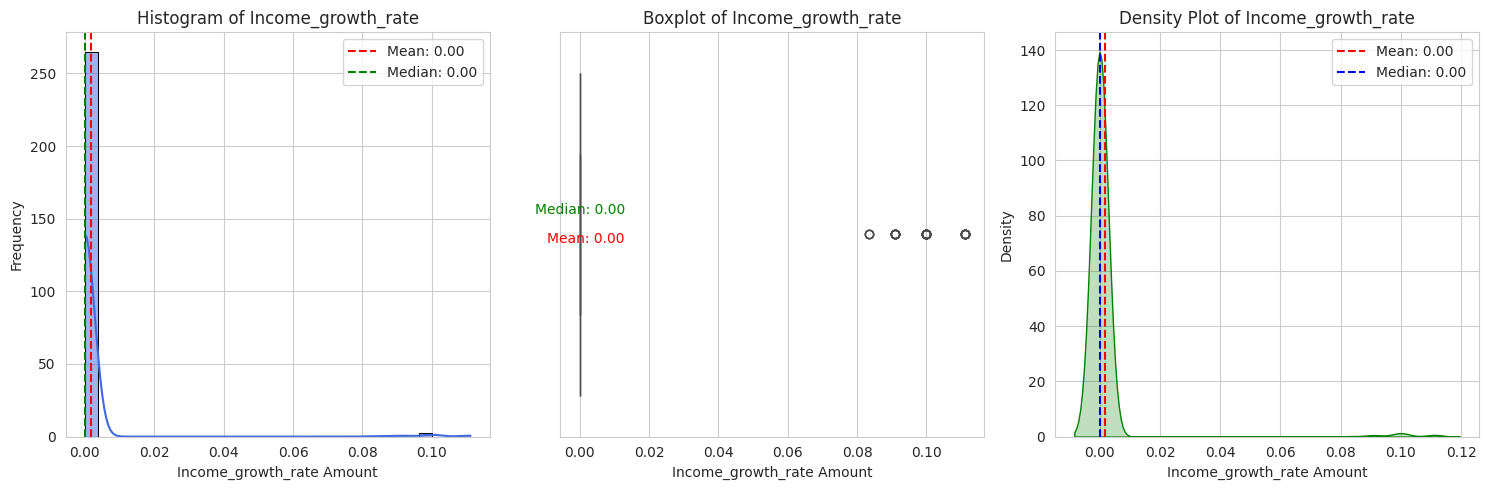

Statistics for Business_per_month:
  Mean   : 312085.36
  Median : 150624.44
  Std Dev: 449570.51
  Min    : -197932.86
  Max    : 3972127.50


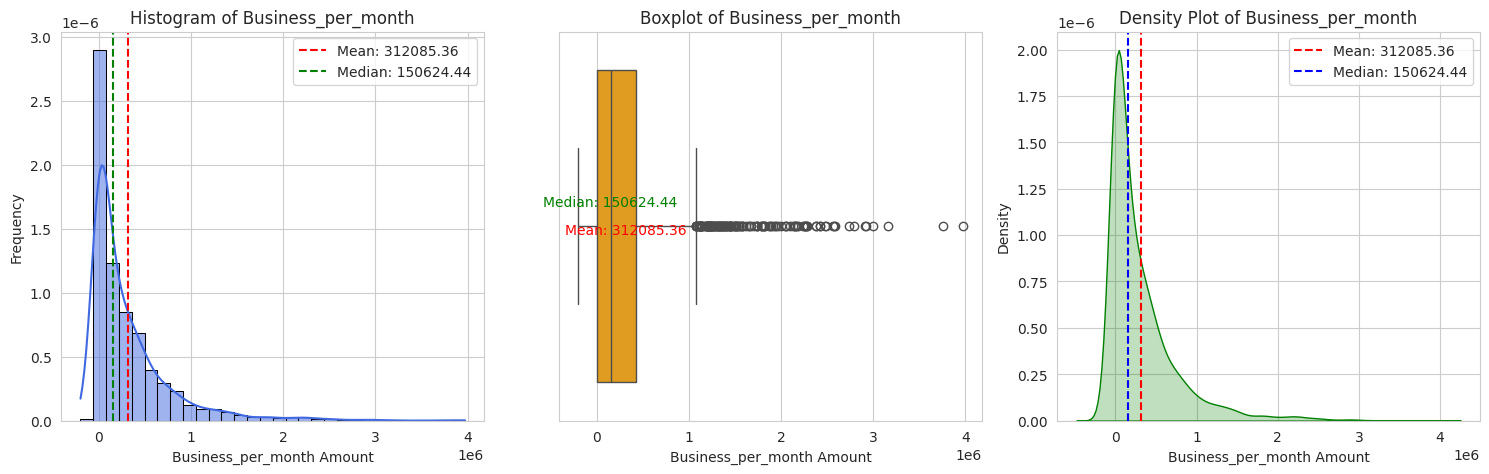

Statistics for Income_per_business:
  Mean   : 16266.41
  Median : 0.34
  Std Dev: 28412.63
  Min    : -10.83
  Max    : 167758.00


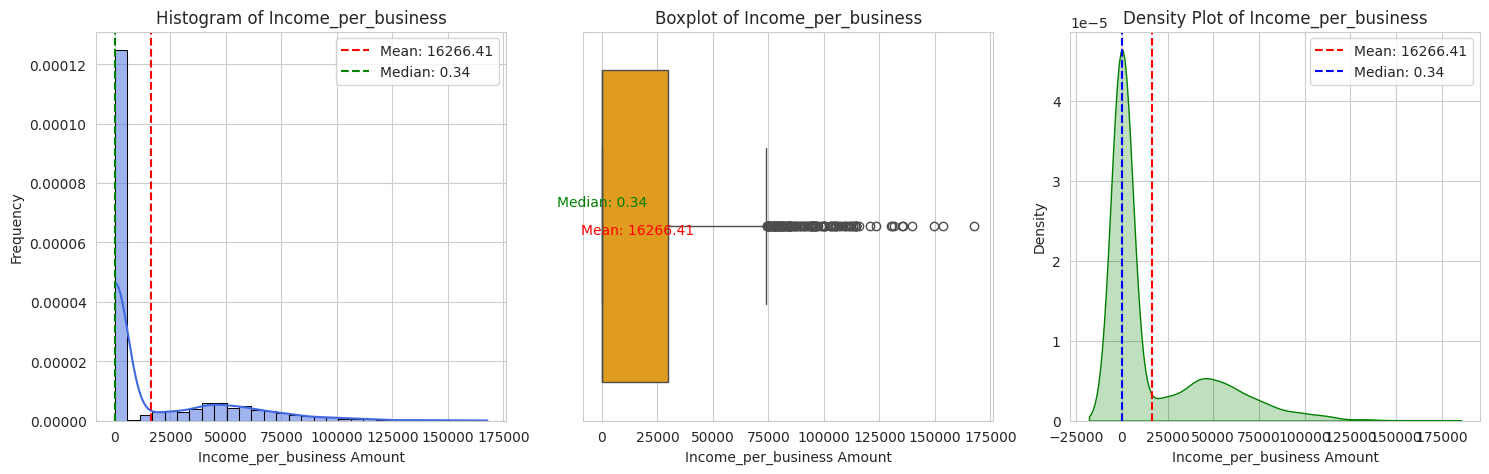

Statistics for Low_rating_flag:
  Mean   : 0.94
  Median : 1.00
  Std Dev: 0.24
  Min    : 0.00
  Max    : 1.00


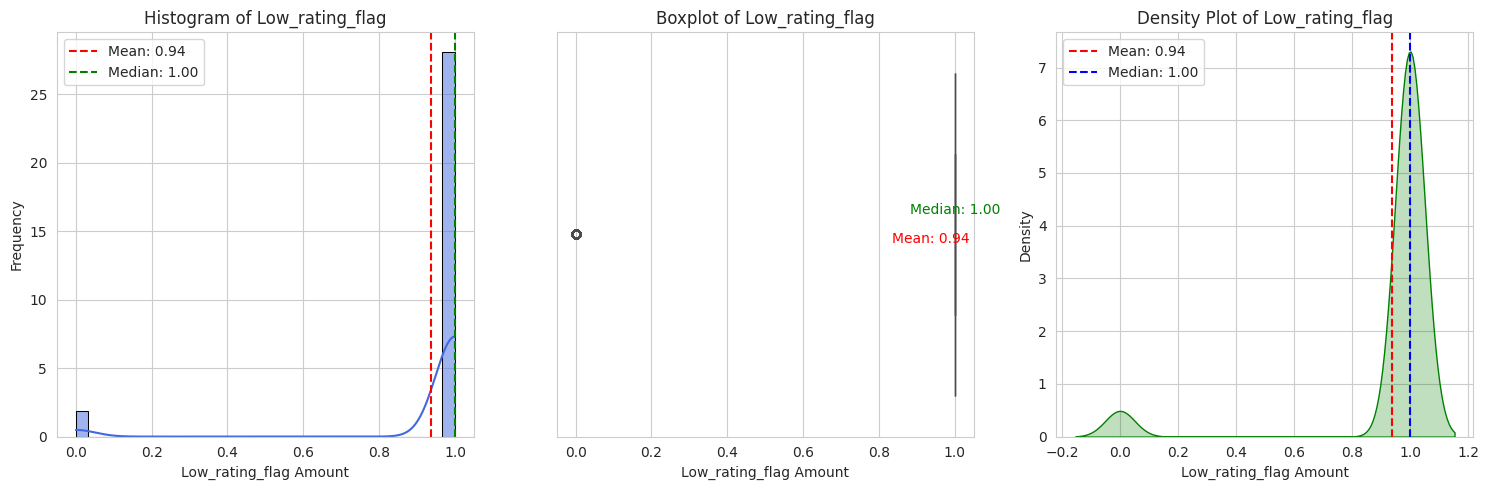

In [64]:
numerical_columns_distribution_with_stats(df_churn)

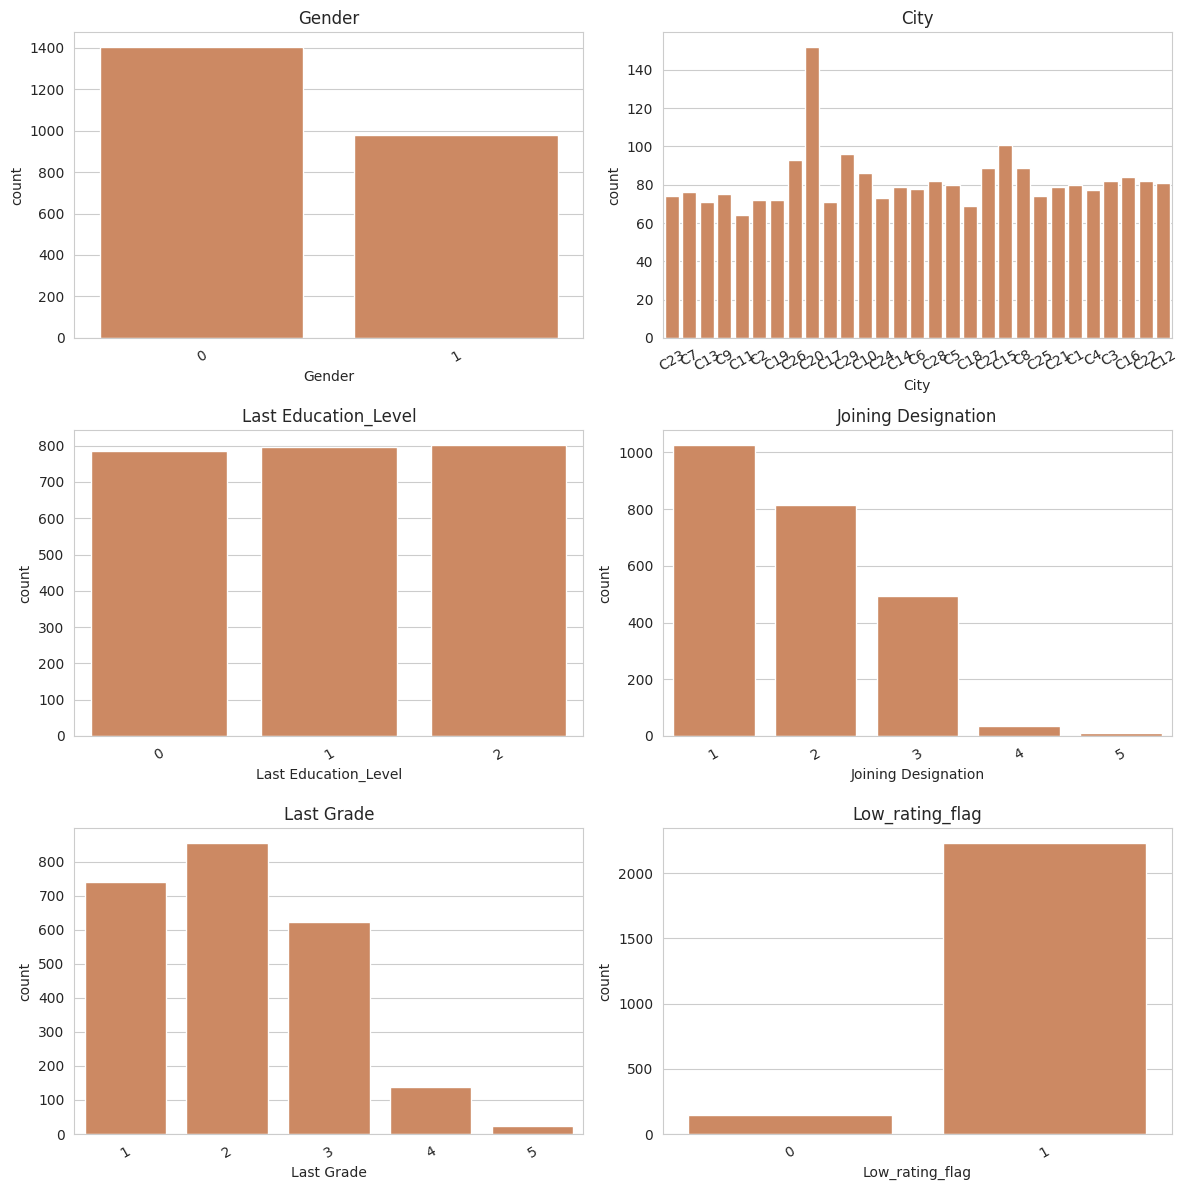

In [63]:
cat_cols = ["Gender","City","Last Education_Level","Joining Designation","Last Grade","Low_rating_flag"]

nrows = math.ceil(len(cat_cols)/2)

fig, axes = plt.subplots(nrows,2,figsize=(12,4*nrows))
axes = axes.flatten()

for i,col in enumerate(cat_cols):
    sns.countplot(data=df_churn,x=col,
                  color=sns.color_palette("deep")[1],
                  ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x",rotation=30)

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

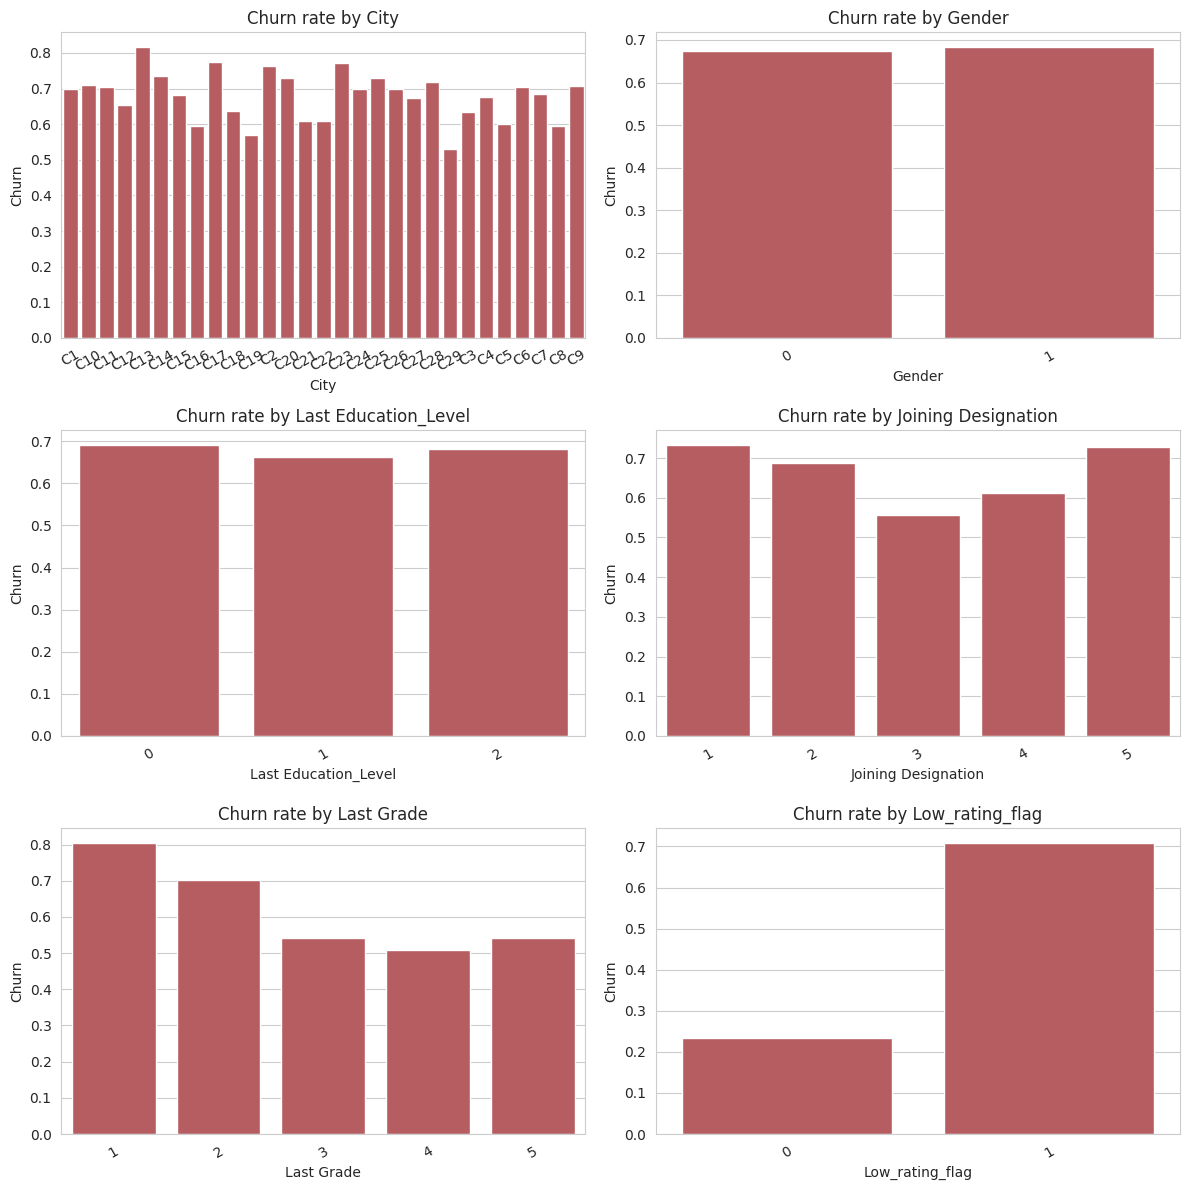

In [ ]:
cat_cols = ["City","Gender","Last Education_Level","Joining Designation","Last Grade","Low_rating_flag"]

nrows = math.ceil(len(cat_cols)/2)

fig, axes = plt.subplots(nrows,2,figsize=(12,4*nrows))
axes = axes.flatten()

for i,col in enumerate(cat_cols):

    churn_rate = df_churn.groupby(col)["Churn"].mean().reset_index()

    sns.barplot(data=churn_rate,
                x=col,
                y="Churn",
                color=sns.color_palette("deep")[3],
                ax=axes[i])

    axes[i].set_title(f"Churn rate by {col}")
    axes[i].tick_params(axis="x",rotation=30)

for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

As it is clearly visible that people with low grade and with low rating are tend to churn more.

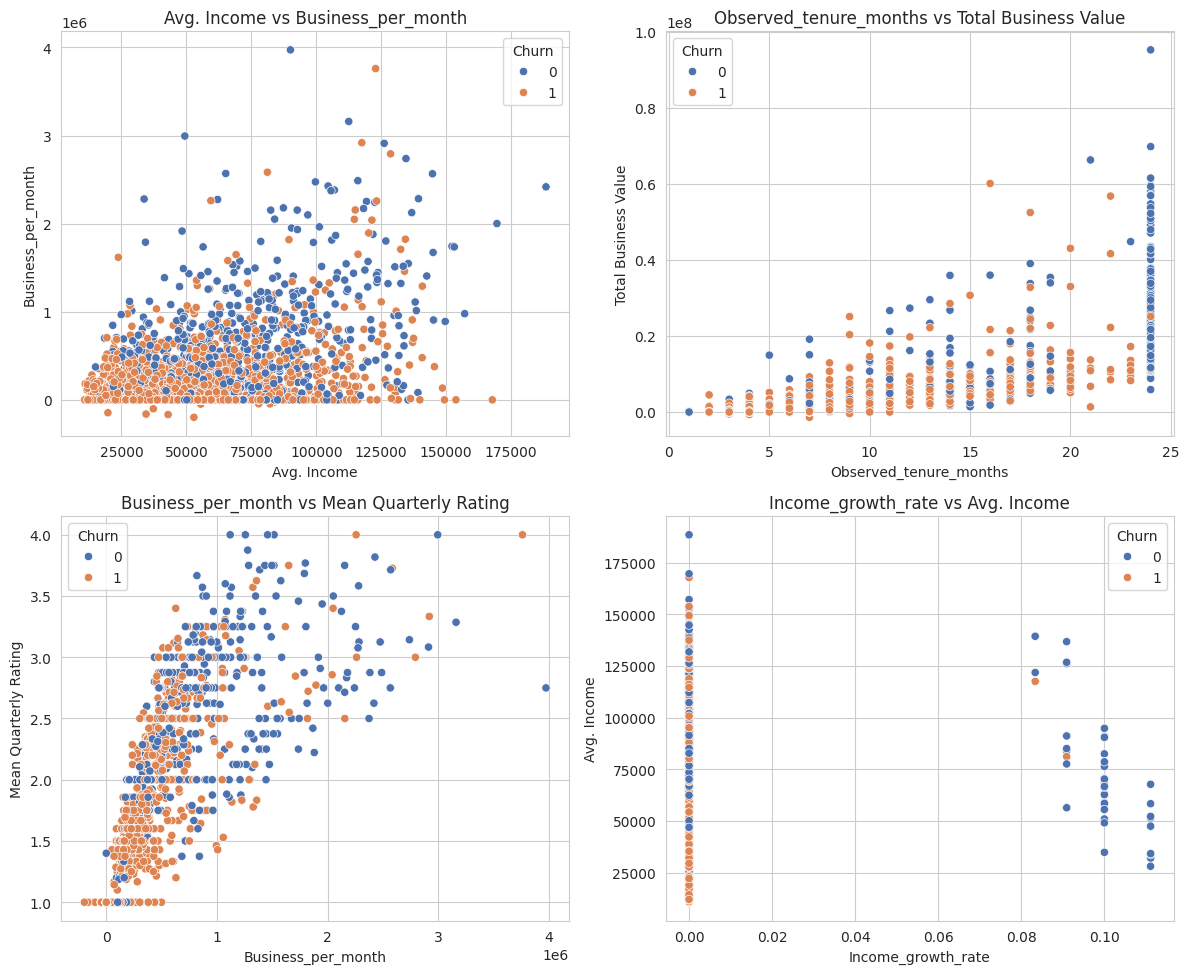

In [ ]:
pairs = [
("Avg. Income","Business_per_month"),
("Observed_tenure_months","Total Business Value"),
("Business_per_month","Mean Quarterly Rating"),
("Income_growth_rate","Avg. Income")
]

fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.flatten()

for i,(x,y) in enumerate(pairs):

    sns.scatterplot(
        data=df_churn,
        x=x,
        y=y,
        hue="Churn",
        palette="deep",
        ax=axes[i]
    )

    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

- Drivers with low business per month and low avg. income churn more.
- Drivers with low observed tenure and low business value churn more.
- Drivers with High mean quarterly rating churn less.
- Drivers having income growth churned less

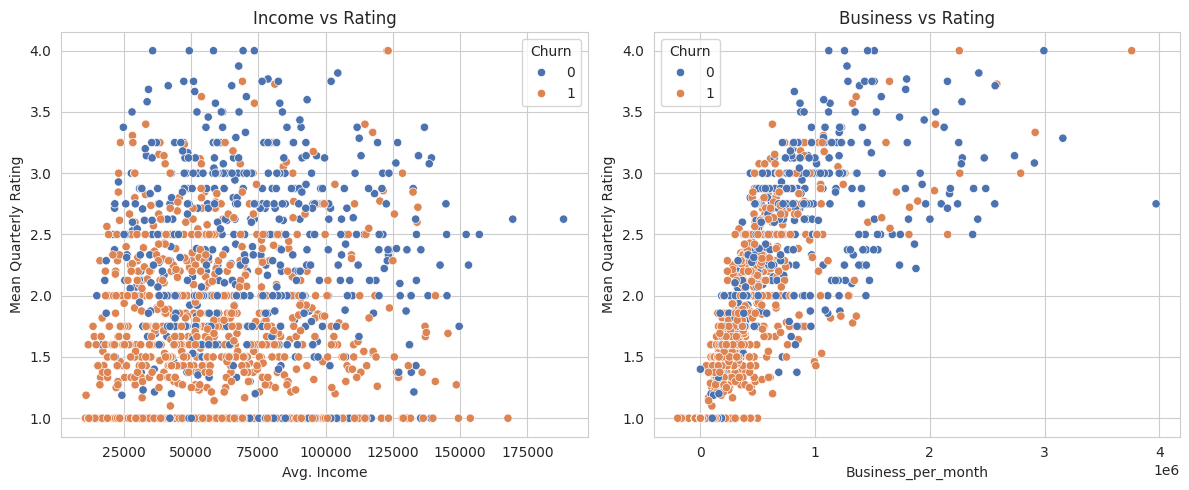

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.scatterplot(
    data=df_churn,
    x="Avg. Income",
    y="Mean Quarterly Rating",
    hue="Churn",
    palette="deep",
    ax=axes[0]
)

sns.scatterplot(
    data=df_churn,
    x="Business_per_month",
    y="Mean Quarterly Rating",
    hue="Churn",
    palette="deep",
    ax=axes[1]
)

axes[0].set_title("Income vs Rating")
axes[1].set_title("Business vs Rating")

plt.tight_layout()
plt.show()

- Drivers with high avg. income ang rating tend to churn less.

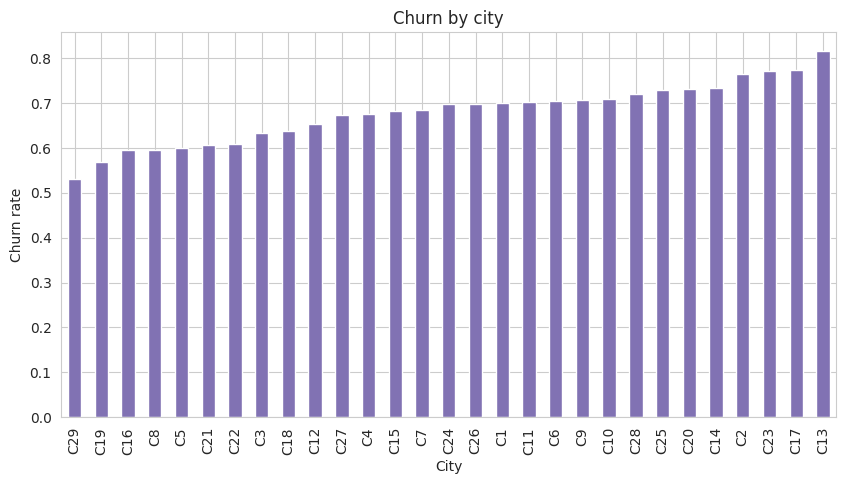

In [ ]:
churn_city = df_churn.groupby("City")["Churn"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10,5))

churn_city.plot(
    kind="bar",
    color=sns.color_palette("deep")[4],
    ax=ax
)

ax.set_ylabel("Churn rate")
ax.set_title("Churn by city")

plt.show()

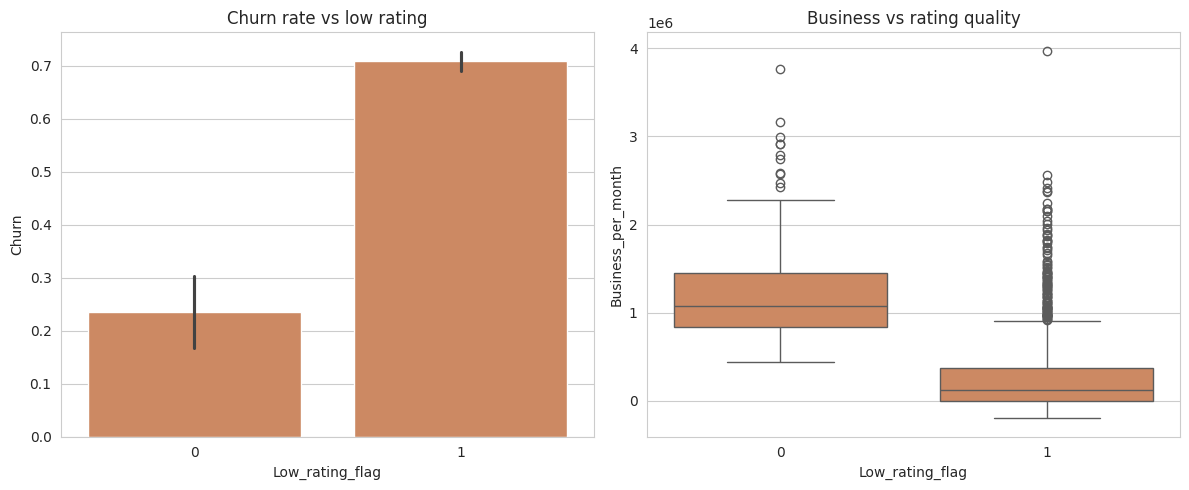

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.barplot(
    data=df_churn,
    x="Low_rating_flag",
    y="Churn",
    color=sns.color_palette("deep")[1],
    ax=axes[0]
)

sns.boxplot(
    data=df_churn,
    x="Low_rating_flag",
    y="Business_per_month",
    color=sns.color_palette("deep")[1],
    ax=axes[1]
)

axes[0].set_title("Churn rate vs low rating")
axes[1].set_title("Business vs rating quality")

plt.tight_layout()
plt.show()

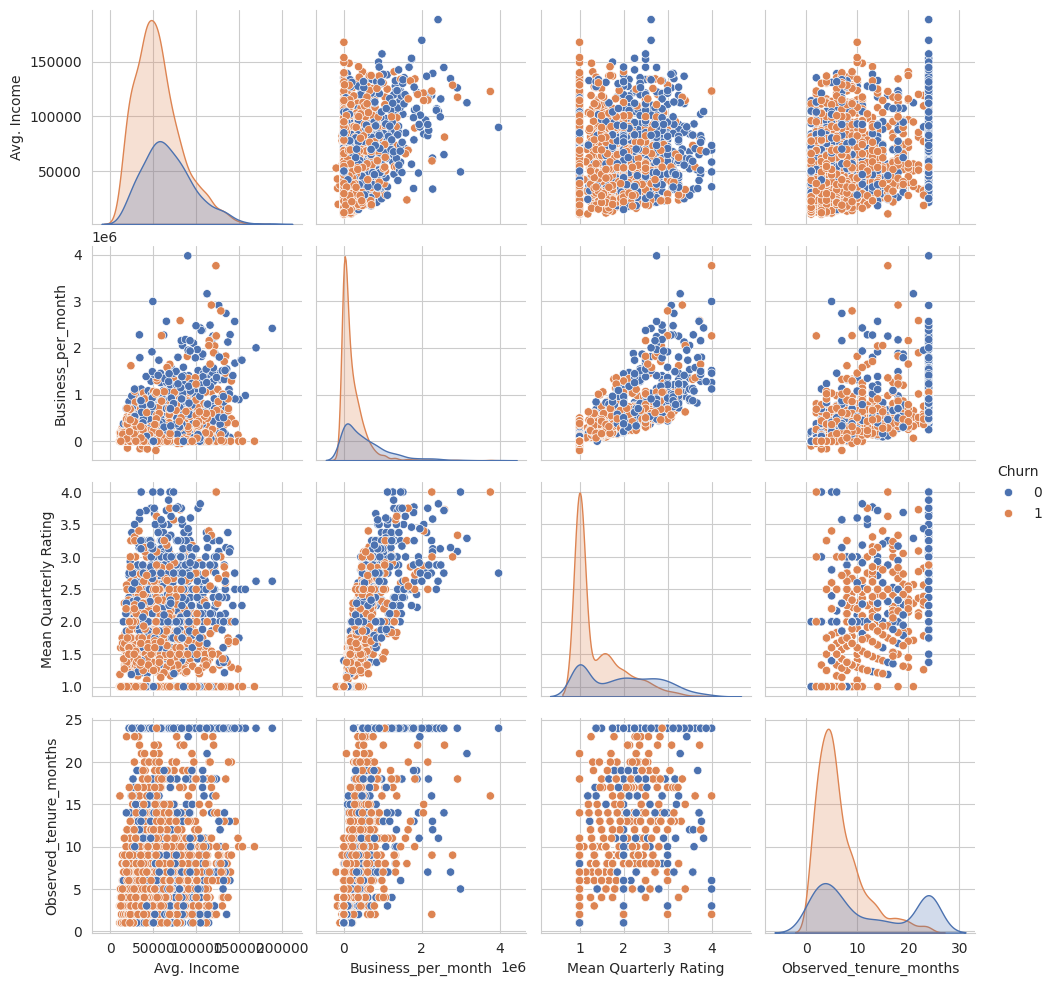

In [ ]:
sns.pairplot(
    df_churn[
        [
            "Avg. Income",
            "Business_per_month",
            "Mean Quarterly Rating",
            "Observed_tenure_months",
            "Churn"
        ]
    ],
    hue="Churn",
    palette="deep"
)
plt.show()

In [ ]:
df_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
Observed_tenure_months,2381.0,8.023520e+00,6.783590e+00,1.000000e+00,3.000000,5.000000,10.00,2.400000e+01
Age,2381.0,3.366317e+01,5.983375e+00,2.100000e+01,29.000000,33.000000,37.00,5.800000e+01
Gender,2381.0,4.103318e-01,4.919972e-01,0.000000e+00,0.000000,0.000000,1.00,1.000000e+00
Last Education_Level,2381.0,1.007560e+00,8.162900e-01,0.000000e+00,0.000000,1.000000,2.00,2.000000e+00
Avg. Income,2381.0,5.923246e+04,2.829821e+04,1.074700e+04,39104.000000,55285.000000,75835.00,1.884180e+05
Joining Designation,2381.0,1.820244e+00,8.414334e-01,1.000000e+00,1.000000,2.000000,2.00,5.000000e+00
Last Grade,2381.0,2.096598e+00,9.415218e-01,1.000000e+00,1.000000,2.000000,3.00,5.000000e+00
Total Business Value,2381.0,4.586742e+06,9.127115e+06,-1.385530e+06,0.000000,817680.000000,4173650.00,9.533106e+07
Mean Quarterly Rating,2381.0,1.566304e+00,7.196520e-01,1.000000e+00,1.000000,1.000000,2.00,4.000000e+00
Churn,2381.0,6.787064e-01,4.670713e-01,0.000000e+00,0.000000,1.000000,1.00,1.000000e+00


### Dataset Summary

* **Total records:** 2,381 drivers
* **Target variable:** `Churn` (1 = driver left, 0 = driver stayed)
* **Average tenure:** ~8 months (range: 1–24 months)

---

### Demographic Insights

* **Average age:** ~34 years
* Most drivers fall between **29–37 years**.
* **Gender distribution:** ~41% in category `1`, ~59% in category `0`.

---

### Education & Role

* Most drivers belong to **Education Level category 1**.
* **Joining designation:** Majority start at **designation level 1–2**.
* **Last grade:** Most drivers remain around **grade level 2–3**.

This indicates **limited promotion progression** for many drivers.

---

### Income Insights

* **Average income:** ~₹59k

* **Median income:** ~₹55k

* Income ranges from **₹10k to ₹188k**.

* **Income growth rate:** ~0.18% on average, indicating **very little salary growth**.

---

### Business Performance

* **Average total business value:** ~₹4.6M.

* The distribution is highly skewed, with a few drivers generating **very large revenue**.

* **Average business per month:** ~₹312k.

* Some **negative values** appear, possibly due to **returns, cancellations, or accounting adjustments**.

---

### Ratings

* **Mean quarterly rating:** ~1.56 (range: 1–4).
* **Low rating flag:** ~94% of drivers fall under low rating.

This suggests ratings are **heavily concentrated on the lower side**.

---

### Churn Insights

* **Churn rate:** ~68%.

About **two-thirds of drivers leave the platform**, indicating a **high attrition environment**.

Possible contributing factors include:

* low ratings
* minimal income growth
* slow career progression

---

### Engineered Features

* **Income per business:** measures earning efficiency relative to generated business.
* **Business per month:** indicates productivity level.
* **Income growth rate:** captures salary progression over time.

These features help represent **driver productivity and compensation dynamics**.

---

### Key Takeaways

* Driver churn is **very high (~68%)**.
* **Income growth is extremely limited**, which may affect retention.
* **Most drivers have low ratings**, suggesting strict evaluation or performance issues.
* Business generation varies significantly across drivers.


In [ ]:
df_churn['Age_bin'] = pd.cut(df_churn['Age'], bins=[18, 30, 50, 100], labels=['Young','Middle-aged','Senior'])

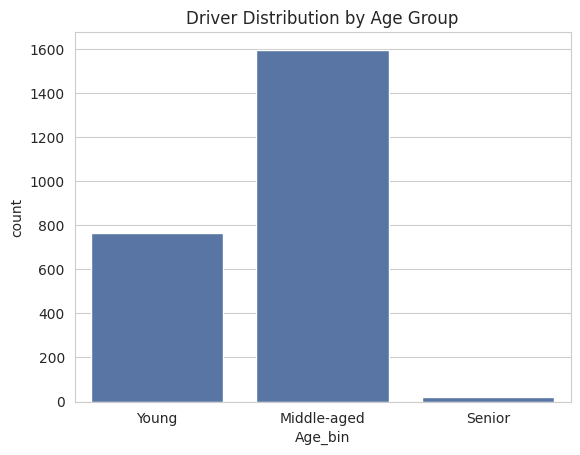

In [ ]:
sns.countplot(data=df_churn, x='Age_bin')
plt.title("Driver Distribution by Age Group")
plt.show()

In [ ]:
df_churn.groupby('Age_bin', observed=True )['Churn'].value_counts(normalize=True)*100

Age_bin      Churn
Young        1        71.204188
             0        28.795812
Middle-aged  1        66.249217
             0        33.750783
Senior       1        70.000000
             0        30.000000
Name: proportion, dtype: float64

Young and Seniors are churning more compared to middle-aged

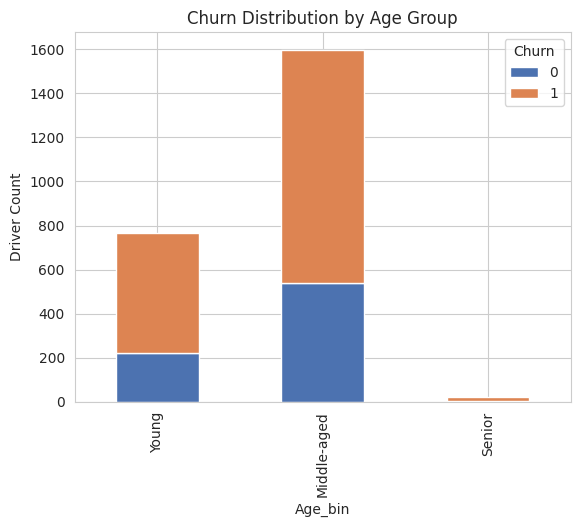

In [ ]:
pd.crosstab(df_churn['Age_bin'], df_churn['Churn']).plot(
    kind='bar',
    stacked=True
)

plt.title("Churn Distribution by Age Group")
plt.ylabel("Driver Count")
plt.show()

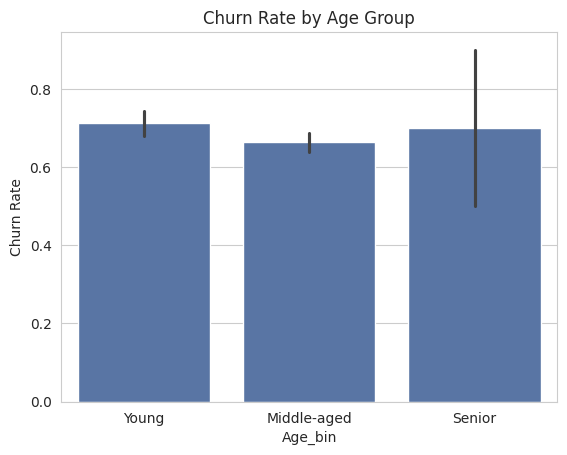

In [ ]:
sns.barplot(
    data=df_churn,
    x='Age_bin',
    y='Churn',
    estimator='mean'
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Age Group")
plt.show()

The churn rate is similar across each age group.

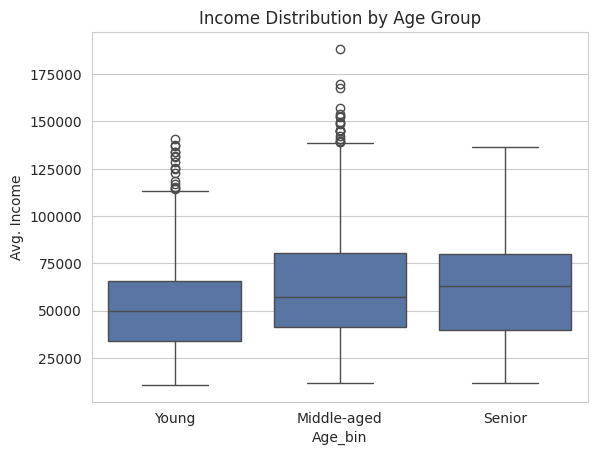

In [ ]:
sns.boxplot(data=df_churn, x='Age_bin', y='Avg. Income')
plt.title("Income Distribution by Age Group")
plt.show()

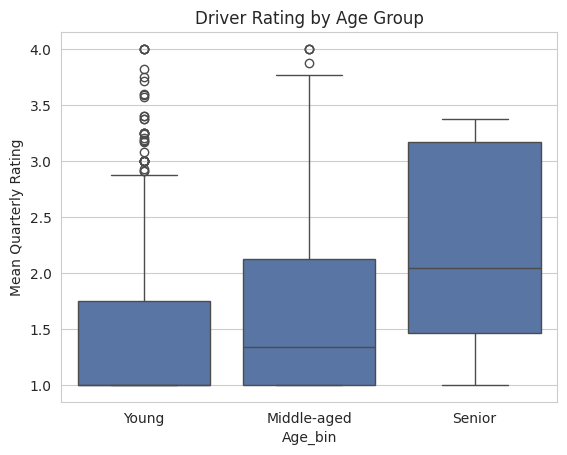

In [ ]:
sns.boxplot(data=df_churn, x='Age_bin', y='Mean Quarterly Rating')
plt.title("Driver Rating by Age Group")
plt.show()

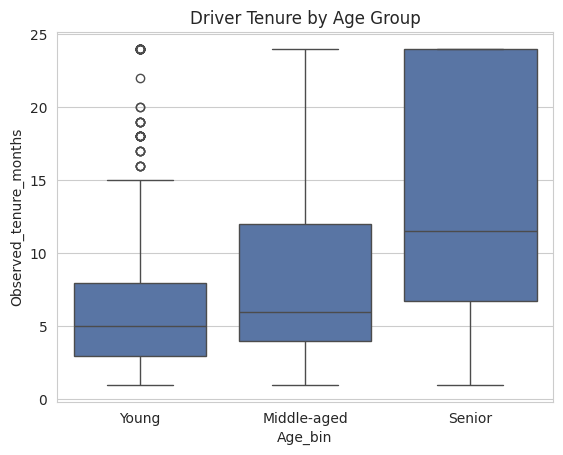

In [ ]:
sns.boxplot(data=df_churn, x='Age_bin', y='Observed_tenure_months')
plt.title("Driver Tenure by Age Group")
plt.show()

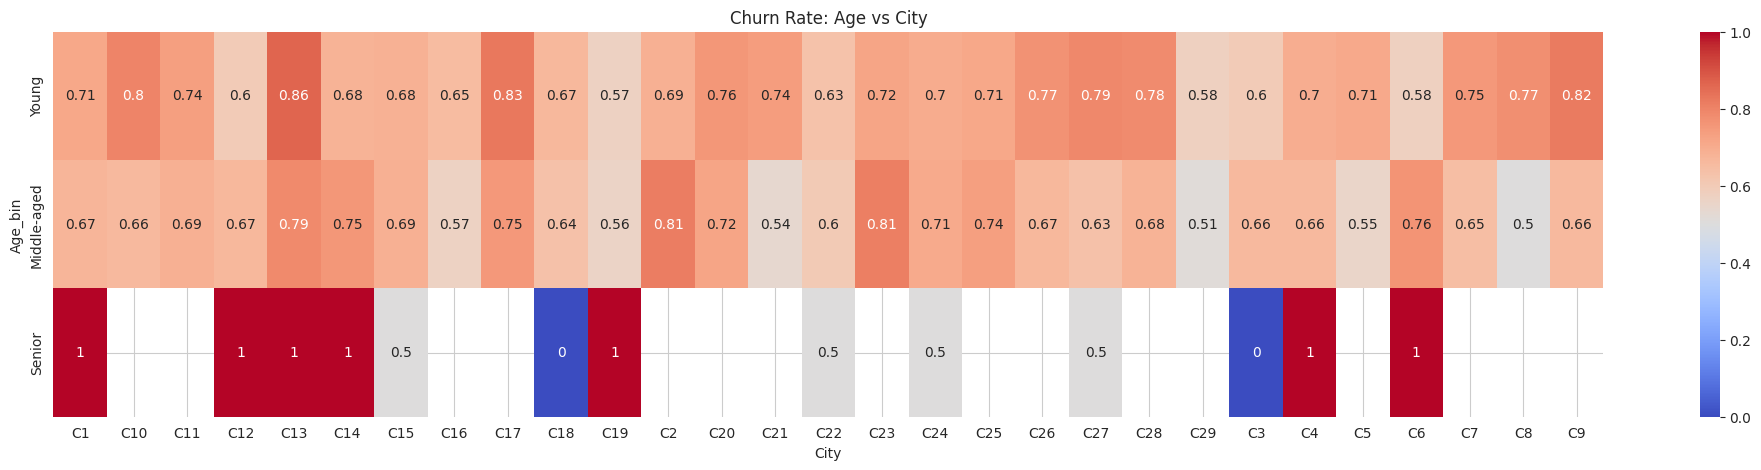

In [ ]:
pivot = pd.pivot_table(
    df_churn,
    values='Churn',
    index='Age_bin',
    columns='City',
    aggfunc='mean',
    observed=True
)

plt.figure(figsize=(25,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Churn Rate: Age vs City")
plt.show()

As the tree ensembling training will apply automatic thresholding, i will remove the age_bin and keep raw Age col

In [ ]:
df_churn.drop(columns=['Age_bin'], inplace=True)

#Model Building

In [65]:
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']

In [66]:
y.value_counts(normalize=True)*100

,proportion
Churn,
1,67.870643
0,32.129357


- As the class imbalance exist, i will initialy use class weight to handle class imbalance.
- As this is not very highly imbalanced dataset so `SMOTE` will not be needed if using class weight make our model identify churn. If not then `Smote` will be used.


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

As i am using ensemble tree learning algorithm(Random Forest, XGBoost, LightGBM) instead of OHE i will label encode them, because Tree models do not assume numeric ordering like linear models do, so label encoding works surprisingly well.

In [68]:
le = LabelEncoder()
X_train["City"] = le.fit_transform(X_train["City"])
X_test["City"] = le.transform(X_test["City"])

Trees split data using thresholds, not distances. The relative ordering of values stays identical after scaling, so the split works the same.So scaling does not improve performance and is basically wasted effort for tree models.

#Bagging (RandomForest)

In [69]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=400,
                       random_state=42)

In [70]:
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:,1]


Classification Report (Default Threshold = 0.5)

              precision    recall  f1-score   support

           0       0.78      0.57      0.66       153
           1       0.82      0.93      0.87       324

    accuracy                           0.81       477
   macro avg       0.80      0.75      0.76       477
weighted avg       0.81      0.81      0.80       477



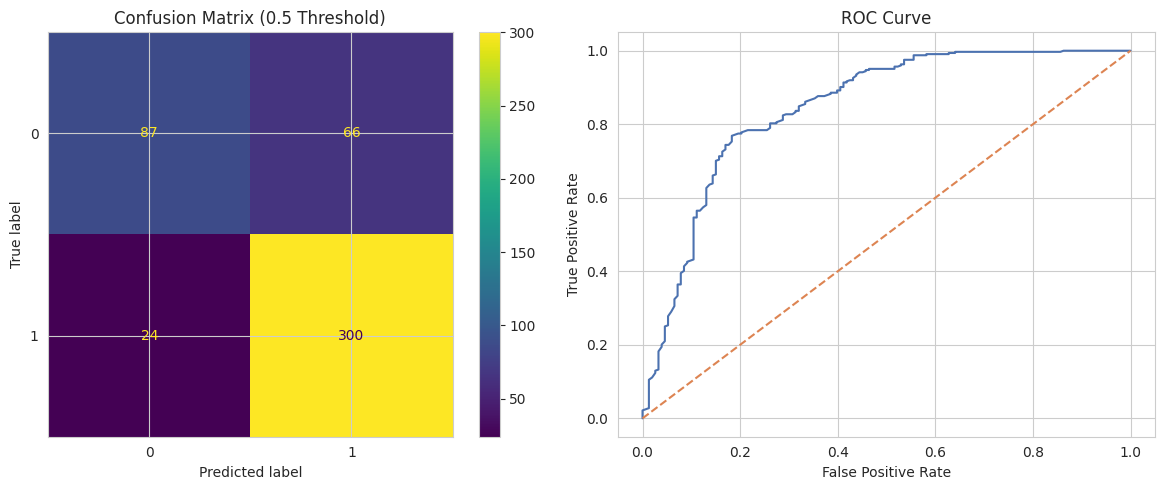


Classification Report (Business Threshold)

              precision    recall  f1-score   support

           0       0.68      0.67      0.68       153
           1       0.84      0.85      0.85       324

    accuracy                           0.79       477
   macro avg       0.76      0.76      0.76       477
weighted avg       0.79      0.79      0.79       477



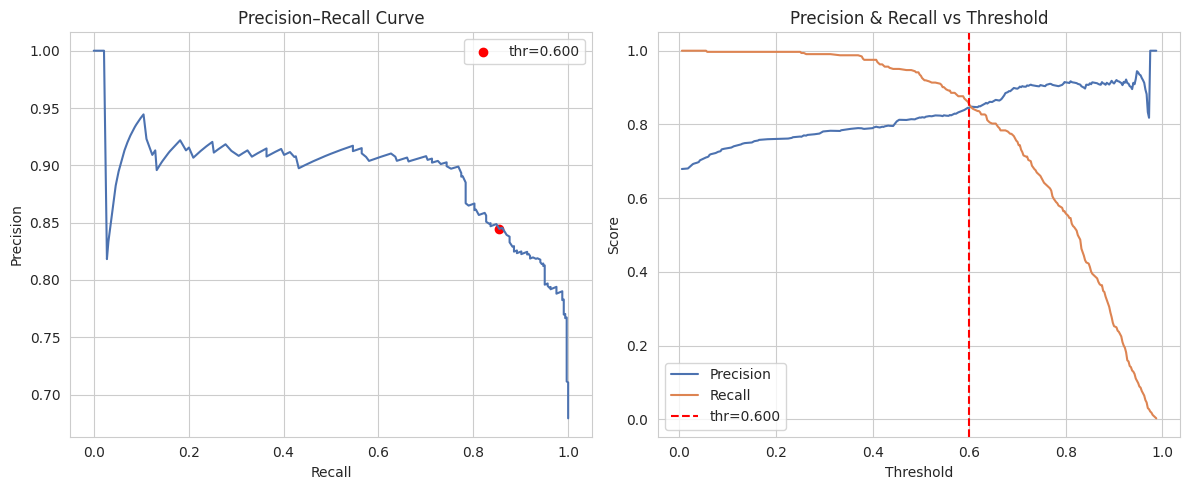


Metrics

accuracy: 0.8113207547169812
precision: 0.819672131147541
recall (TPR): 0.9259259259259259
f1_score: 0.8695652173913043
mcc: 0.5462976849148992
TPR: 0.9259259259259259
TNR: 0.5686274509803921
FPR: 0.43137254901960786
FNR: 0.07407407407407407
TP: 300
TN: 87
FP: 66
FN: 24
roc_auc: 0.8460421205519244
pr_auc: 0.8927159501147114
business_threshold: 0.6


In [71]:
evaluate_classifier(y_test, pred, proba)

- Model has about an 85%(roc_auc) probability of ranking a churned driver higher than a non-churned driver. ROC-AUC 0.846 : strong discrimination ability

- Model identifies churners much more accurately than random selection. PR-AUC 0.893 : excellent precision-recall tradeoff for churn detection.

That indicates good class separation.

As `GridSearchCV` will waste computation and `RandomSearchCV` will search blindly i use `Optuna` which use Bayesian optimization to learn which regions of the parameter space look promising.

In [73]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_categorical("n_estimators", [200,400,600,800,1000]),
        "max_depth": trial.suggest_categorical("max_depth", [6,8,10,12,14]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [5,10,20,30]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [5,10,20]),
        "max_features": trial.suggest_categorical("max_features", [0.3,0.5,0.8,"sqrt","log2"]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="average_precision",
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=50)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-03-05 08:54:21,238] A new study created in memory with name: no-name-ec483e0b-1d37-4632-b499-ed88fe694a54
[I 2026-03-05 08:54:31,874] Trial 0 finished with value: 0.8941160977790702 and parameters: {'n_estimators': 400, 'max_depth': 8, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8941160977790702.
[I 2026-03-05 08:54:50,208] Trial 1 finished with value: 0.8915617492315977 and parameters: {'n_estimators': 1000, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 0.3, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8941160977790702.
[I 2026-03-05 08:54:59,733] Trial 2 finished with value: 0.8920215513327505 and parameters: {'n_estimators': 400, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 0.8, 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.89411609777907

Best Score: 0.8954445398119582
Best Params: {'n_estimators': 800, 'max_depth': 8, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True, 'class_weight': 'balanced'}


In [75]:
best_params = study.best_params

best_rf = RandomForestClassifier(**best_params, random_state=42)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, max_features=0.8,
                       min_samples_leaf=10, min_samples_split=30,
                       n_estimators=800, random_state=42)


Classification Report (Default Threshold = 0.5)

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       153
           1       0.86      0.85      0.86       324

    accuracy                           0.81       477
   macro avg       0.78      0.78      0.78       477
weighted avg       0.81      0.81      0.81       477



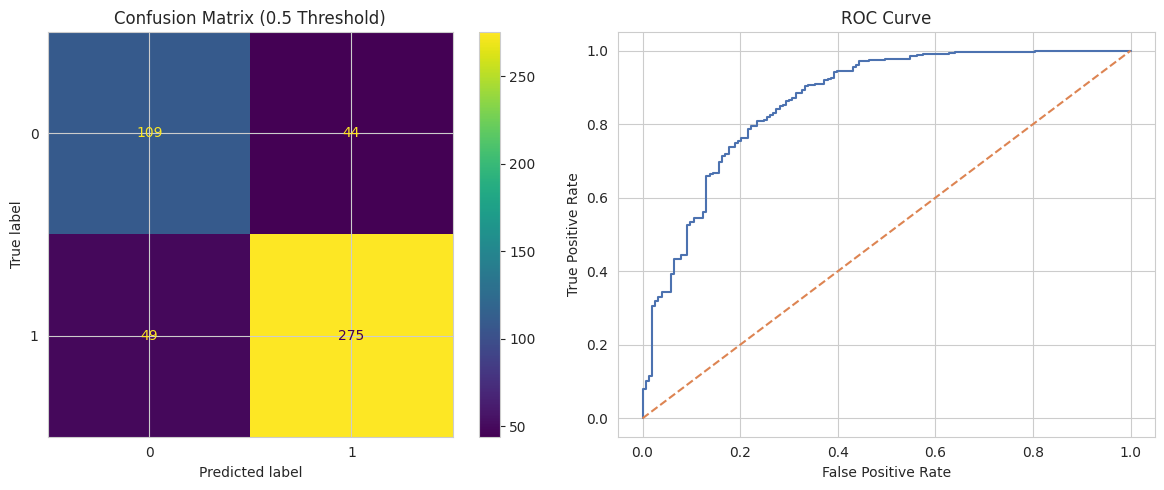


Classification Report (Business Threshold)

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       153
           1       0.86      0.85      0.86       324

    accuracy                           0.81       477
   macro avg       0.78      0.78      0.78       477
weighted avg       0.81      0.81      0.81       477



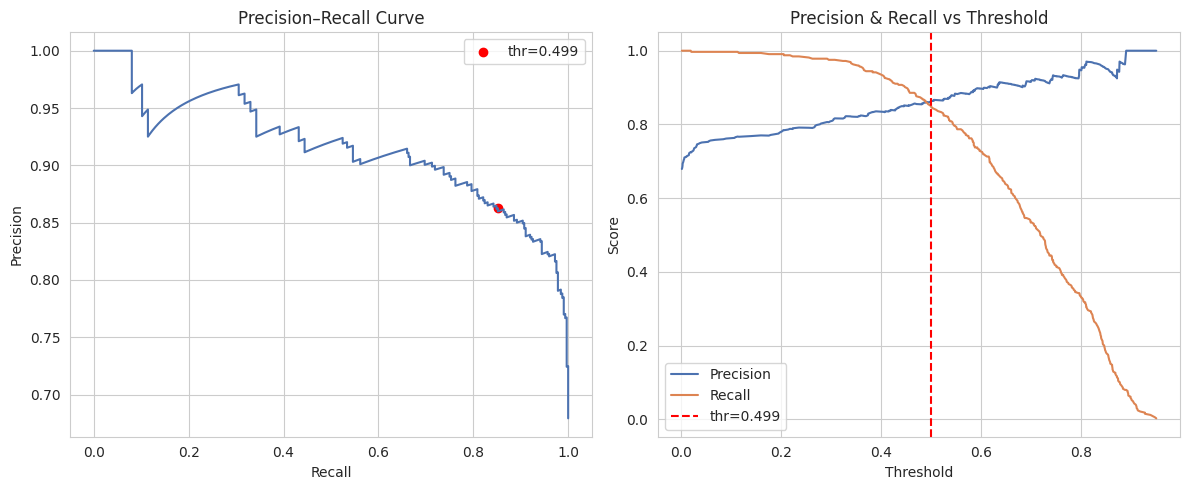


Metrics

accuracy: 0.8050314465408805
precision: 0.8620689655172413
recall (TPR): 0.8487654320987654
f1_score: 0.8553654743390358
mcc: 0.5565438768777905
TPR: 0.8487654320987654
TNR: 0.7124183006535948
FPR: 0.2875816993464052
FNR: 0.15123456790123457
TP: 275
TN: 109
FP: 44
FN: 49
roc_auc: 0.864479948357944
pr_auc: 0.9155395827091739
business_threshold: 0.499272461450392


In [76]:
pred = best_rf.predict(X_test)
proba = best_rf.predict_proba(X_test)[:,1]
evaluate_classifier(y_test, pred, proba)

Both roc_auc and pr_auc increased after tunning

In [77]:
thresholds = np.arange(0.1,0.9,0.05)

for t in thresholds:
    pred = (proba > t).astype(int)
    print(t, recall_score(y_test, pred), precision_score(y_test, pred))

0.1 0.9969135802469136 0.7635933806146572
0.15000000000000002 0.9938271604938271 0.7703349282296651
0.20000000000000004 0.9907407407407407 0.781021897810219
0.25000000000000006 0.9814814814814815 0.7910447761194029
0.30000000000000004 0.9753086419753086 0.8102564102564103
0.3500000000000001 0.9598765432098766 0.820580474934037
0.40000000000000013 0.9351851851851852 0.8347107438016529
0.45000000000000007 0.8981481481481481 0.8508771929824561
0.5000000000000001 0.8487654320987654 0.8620689655172413
0.5500000000000002 0.7932098765432098 0.8831615120274914
0.6000000000000002 0.7253086419753086 0.8969465648854962
0.6500000000000001 0.6358024691358025 0.911504424778761
0.7000000000000002 0.5339506172839507 0.9153439153439153
0.7500000000000002 0.4166666666666667 0.9310344827586207
0.8000000000000002 0.3333333333333333 0.9473684210526315
0.8500000000000002 0.18518518518518517 0.9523809523809523


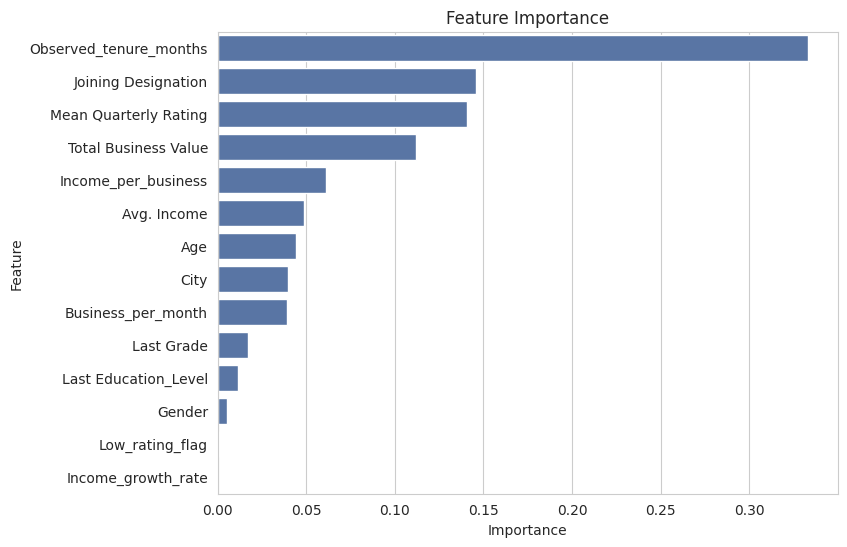

,feature,importance
0,Observed_tenure_months,3.332966e-01
6,Joining Designation,1.459136e-01
9,Mean Quarterly Rating,1.404950e-01
8,Total Business Value,1.120505e-01
12,Income_per_business,6.112440e-02
5,Avg. Income,4.878259e-02
1,Age,4.445345e-02
3,City,3.994222e-02
11,Business_per_month,3.912472e-02
7,Last Grade,1.707968e-02


In [78]:
plot_feature_importance(best_rf, X_train)

#Boosting

##XGBoost

In [79]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

ratio = neg / pos

In [82]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_categorical("n_estimators",[200,300,400,500,600,700]),
        "max_depth": trial.suggest_categorical("max_depth",[3,4,5,6]),
        "learning_rate": trial.suggest_categorical("learning_rate",[0.01,0.05,0.1]),
        "subsample": trial.suggest_categorical("subsample",[0.7,0.8,0.9,1]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree",[0.7,0.8,0.9,1]),
        "gamma": trial.suggest_categorical("gamma",[0,0.1,0.3]),
        "min_child_weight": trial.suggest_categorical("min_child_weight",[1,3,5]),

        # key parameter for imbalance
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            ratio*0.5,
            ratio*1.5
        ),

        "eval_metric":"aucpr",
        "random_state":42,
        "n_jobs":-1
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="average_precision",   # PR-AUC
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-05 09:21:41,594] A new study created in memory with name: no-name-1c05c090-73b9-458a-8373-d45c93cc1ba5
[I 2026-03-05 09:21:47,627] Trial 0 finished with value: 0.8918348423789819 and parameters: {'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1, 'colsample_bytree': 0.8, 'gamma': 0.1, 'min_child_weight': 5, 'scale_pos_weight': 0.6099048235897795}. Best is trial 0 with value: 0.8918348423789819.
[I 2026-03-05 09:21:49,350] Trial 1 finished with value: 0.8762377041757891 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9, 'gamma': 0.1, 'min_child_weight': 3, 'scale_pos_weight': 0.4937010890406158}. Best is trial 0 with value: 0.8918348423789819.
[I 2026-03-05 09:21:50,116] Trial 2 finished with value: 0.9006297223220102 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 1, 'colsample_bytree': 0.9, 'gamma': 0, 'min_child_weight': 1, 'scale_pos_weight

Best score: 0.9068486823124555
Best params: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 1, 'colsample_bytree': 0.8, 'gamma': 0.3, 'min_child_weight': 5, 'scale_pos_weight': 0.5827384033340766}


In [83]:
best_params = study.best_params

best_xgb = XGBClassifier(**best_params, eval_metric="aucpr", random_state=42)

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)


Classification Report (Default Threshold = 0.5)

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       153
           1       0.86      0.86      0.86       324

    accuracy                           0.81       477
   macro avg       0.78      0.78      0.78       477
weighted avg       0.81      0.81      0.81       477



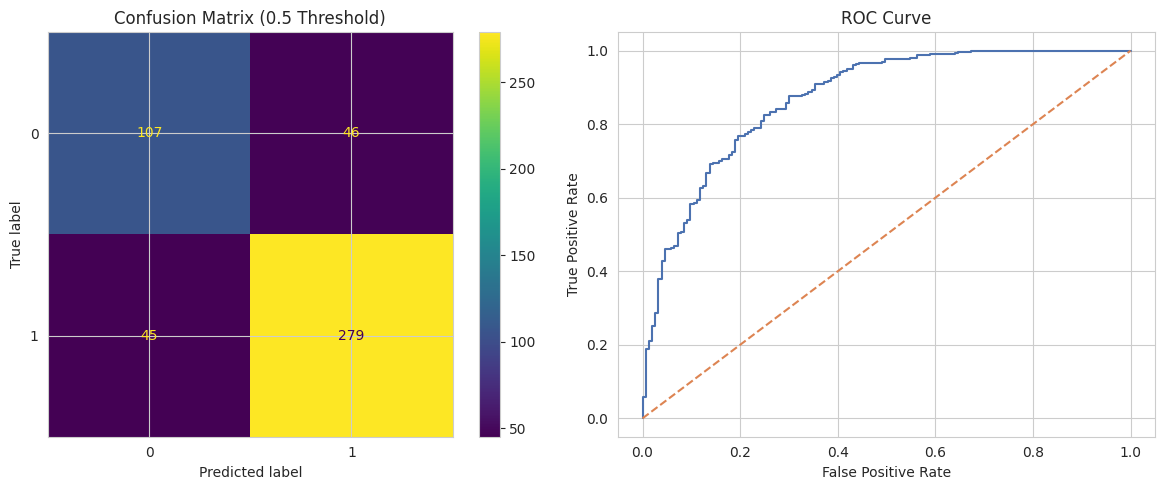


Classification Report (Business Threshold)

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       153
           1       0.86      0.85      0.86       324

    accuracy                           0.81       477
   macro avg       0.78      0.78      0.78       477
weighted avg       0.81      0.81      0.81       477



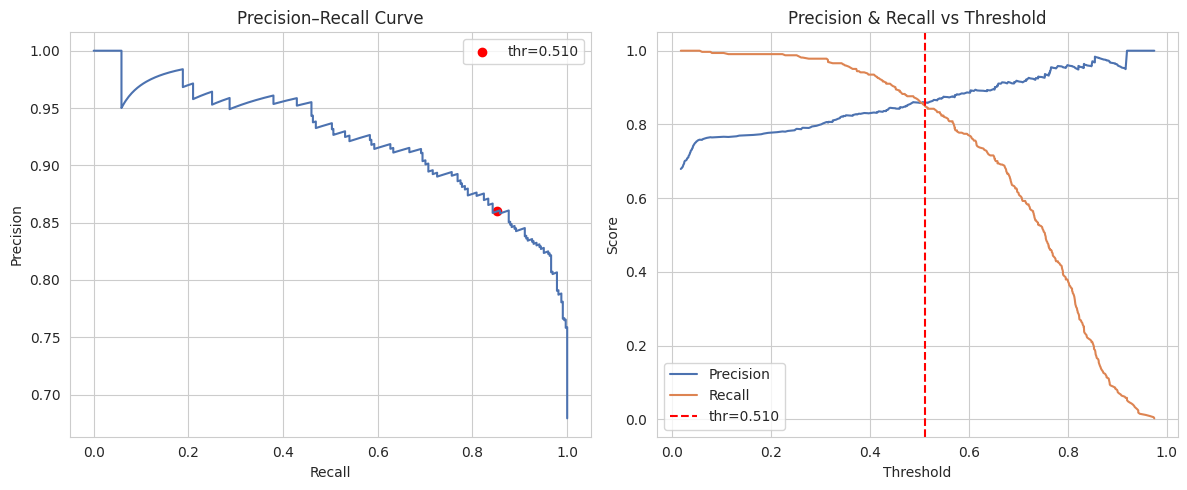


Metrics

accuracy: 0.8092243186582809
precision: 0.8584615384615385
recall (TPR): 0.8611111111111112
f1_score: 0.8597842835130971
mcc: 0.5614323637971343
TPR: 0.8611111111111112
TNR: 0.6993464052287581
FPR: 0.3006535947712418
FNR: 0.1388888888888889
TP: 279
TN: 107
FP: 46
FN: 45
roc_auc: 0.871036068748487
pr_auc: 0.9229867492446533
business_threshold: 0.5104468464851379


In [84]:
pred = best_xgb.predict(X_test)
proba = best_xgb.predict_proba(X_test)[:,1]
evaluate_classifier(y_test, pred, proba)

Slight increase of roc_auc and pr_auc from rf

In [85]:
thresholds = np.arange(0.1,0.9,0.05)

for t in thresholds:
    pred = (proba > t).astype(int)
    print(t, recall_score(y_test, pred), precision_score(y_test, pred))

0.1 0.9938271604938271 0.7666666666666667
0.15000000000000002 0.9907407407407407 0.7716346153846154
0.20000000000000004 0.9907407407407407 0.779126213592233
0.25000000000000006 0.9876543209876543 0.7881773399014779
0.30000000000000004 0.9783950617283951 0.8005050505050505
0.3500000000000001 0.9598765432098766 0.8249336870026526
0.40000000000000013 0.9351851851851852 0.8324175824175825
0.45000000000000007 0.9012345679012346 0.8439306358381503
0.5000000000000001 0.8611111111111112 0.8584615384615385
0.5500000000000002 0.8179012345679012 0.8745874587458746
0.6000000000000002 0.7685185185185185 0.8861209964412812
0.6500000000000001 0.7129629629629629 0.8953488372093024
0.7000000000000002 0.6141975308641975 0.9170506912442397
0.7500000000000002 0.5123456790123457 0.9273743016759777
0.8000000000000002 0.3734567901234568 0.9603174603174603
0.8500000000000002 0.20679012345679013 0.9710144927536232


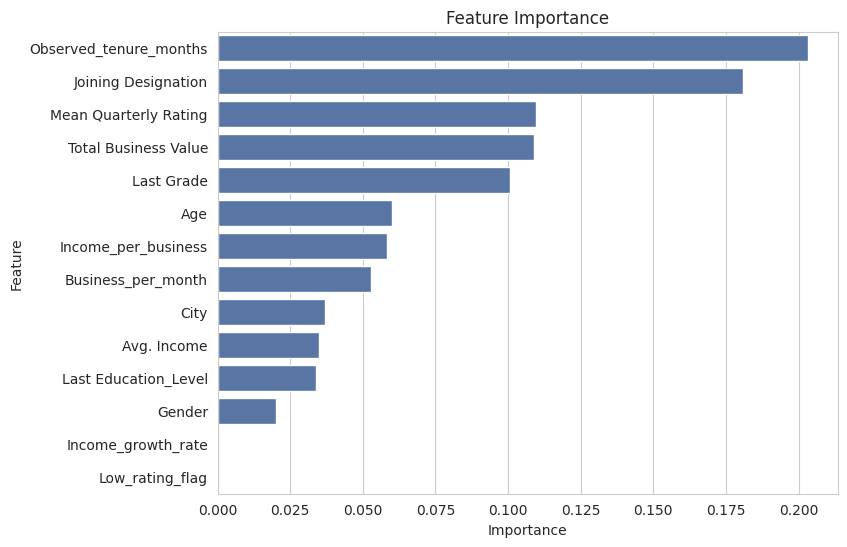

,feature,importance
0,Observed_tenure_months,0.203295
6,Joining Designation,0.180900
9,Mean Quarterly Rating,0.109709
8,Total Business Value,0.108891
7,Last Grade,0.100571
1,Age,0.060021
12,Income_per_business,0.058143
11,Business_per_month,0.052692
3,City,0.036835
5,Avg. Income,0.034900


In [86]:
plot_feature_importance(best_xgb, X_train)

##LightGBM

In [89]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_categorical("n_estimators",[200,300,400,500]),
        "max_depth": trial.suggest_categorical("max_depth",[-1,4,6,8]),
        "learning_rate": trial.suggest_categorical("learning_rate",[0.01,0.05,0.1]),
        "num_leaves": trial.suggest_categorical("num_leaves",[20,30,40,50]),
        "subsample": trial.suggest_categorical("subsample",[0.7,0.8,0.9,1]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree",[0.7,0.8,0.9,1]),
        "min_child_samples": trial.suggest_categorical("min_child_samples",[10,20,30]),

        # imbalance handling
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            ratio*0.5,
            ratio*1.5
        ),

        "objective": "binary",
        "n_jobs": -1,
        "random_state": 42
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="average_precision",   # PR-AUC
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=60)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-03-05 09:26:43,017] A new study created in memory with name: no-name-aedb52cf-0111-4196-932a-c377f388efb6
[I 2026-03-05 09:26:56,558] Trial 0 finished with value: 0.876287903960544 and parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'num_leaves': 20, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_samples': 20, 'scale_pos_weight': 0.4945775952764764}. Best is trial 0 with value: 0.876287903960544.
[I 2026-03-05 09:27:02,258] Trial 1 finished with value: 0.8744125885973346 and parameters: {'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1, 'num_leaves': 30, 'subsample': 0.7, 'colsample_bytree': 0.9, 'min_child_samples': 20, 'scale_pos_weight': 0.49130891551393896}. Best is trial 0 with value: 0.876287903960544.
[I 2026-03-05 09:27:05,633] Trial 2 finished with value: 0.8948819150165587 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'num_leaves': 20, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_samples'

Best Score: 0.9082649948313778
Best Params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'num_leaves': 40, 'subsample': 1, 'colsample_bytree': 0.9, 'min_child_samples': 30, 'scale_pos_weight': 0.2775240360372231}


In [92]:
best_params = study.best_params

best_lgb = LGBMClassifier(**best_params, random_state=42)

best_lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1292, number of negative: 612
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1209
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.678571 -> initscore=0.747214
[LightGBM] [Info] Start training from score 0.747214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMClassifier(colsample_bytree=0.9, learning_rate=0.01, max_depth=4,
               min_child_samples=30, n_estimators=400, num_leaves=40,
               random_state=42, scale_pos_weight=0.2775240360372231,
               subsample=1)


Classification Report (Default Threshold = 0.5)

              precision    recall  f1-score   support

           0       0.53      0.87      0.66       153
           1       0.91      0.64      0.75       324

    accuracy                           0.71       477
   macro avg       0.72      0.76      0.71       477
weighted avg       0.79      0.71      0.72       477



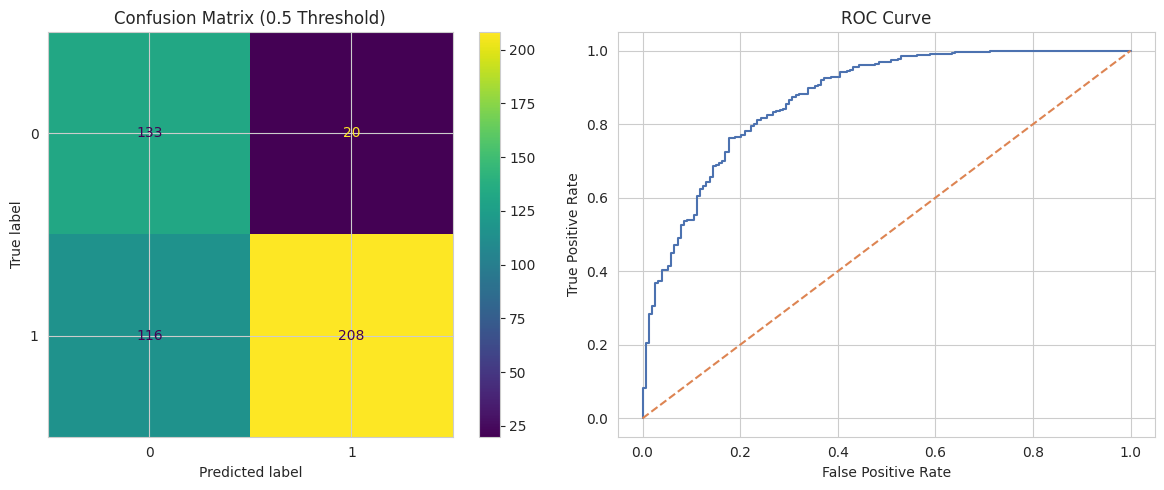


Classification Report (Business Threshold)

              precision    recall  f1-score   support

           0       0.69      0.71      0.70       153
           1       0.86      0.85      0.86       324

    accuracy                           0.81       477
   macro avg       0.78      0.78      0.78       477
weighted avg       0.81      0.81      0.81       477



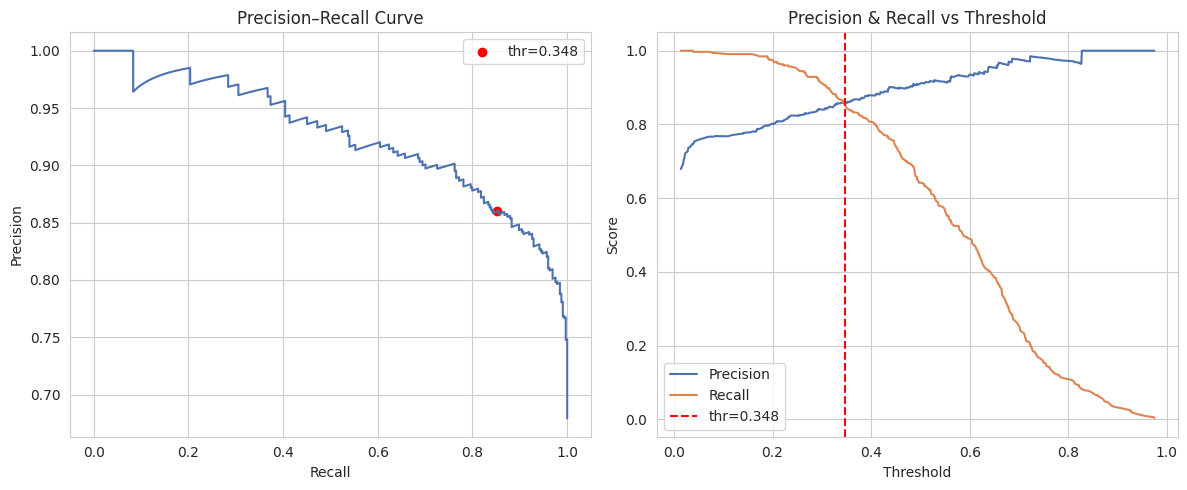


Metrics

accuracy: 0.7148846960167715
precision: 0.9122807017543859
recall (TPR): 0.6419753086419753
f1_score: 0.7536231884057971
mcc: 0.4777380607820409
TPR: 0.6419753086419753
TNR: 0.869281045751634
FPR: 0.13071895424836602
FNR: 0.35802469135802467
TP: 208
TN: 133
FP: 20
FN: 116
roc_auc: 0.8715605583797305
pr_auc: 0.9253314007465134
business_threshold: 0.3477652520646052


In [93]:
pred = best_lgb.predict(X_test)
proba = best_lgb.predict_proba(X_test)[:,1]
evaluate_classifier(y_test, pred, proba)

In [94]:
thresholds = np.arange(0.1,0.9,0.05)

for t in thresholds:
    pred = (proba > t).astype(int)
    print(t, recall_score(y_test, pred), precision_score(y_test, pred))

0.1 0.9907407407407407 0.7679425837320574
0.15000000000000002 0.9907407407407407 0.779126213592233
0.20000000000000004 0.9722222222222222 0.8015267175572519
0.25000000000000006 0.9506172839506173 0.8235294117647058
0.30000000000000004 0.9104938271604939 0.8404558404558404
0.3500000000000001 0.8425925925925926 0.8584905660377359
0.40000000000000013 0.8055555555555556 0.8787878787878788
0.45000000000000007 0.7376543209876543 0.8984962406015038
0.5000000000000001 0.6419753086419753 0.9122807017543859
0.5500000000000002 0.5679012345679012 0.9154228855721394
0.6000000000000002 0.4876543209876543 0.9349112426035503
0.6500000000000001 0.38271604938271603 0.9538461538461539
0.7000000000000002 0.25308641975308643 0.9761904761904762
0.7500000000000002 0.15123456790123457 0.98
0.8000000000000002 0.10802469135802469 0.9722222222222222
0.8500000000000002 0.07098765432098765 1.0


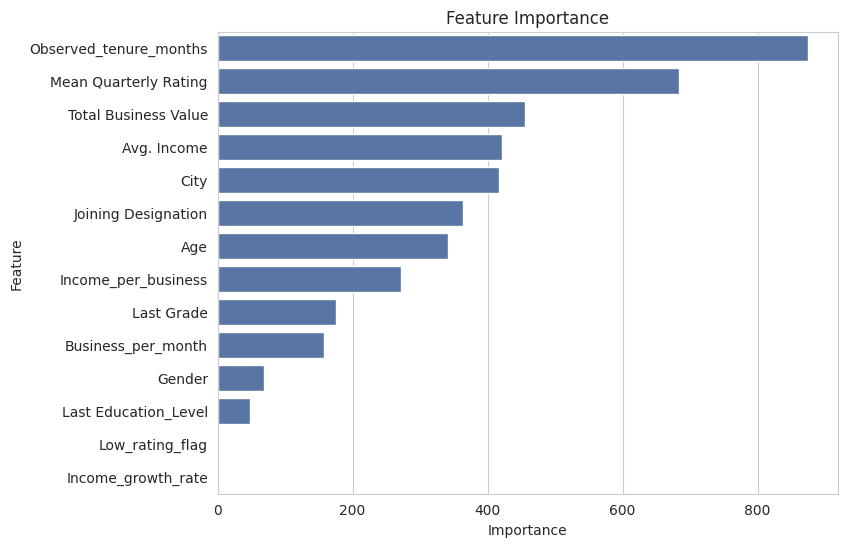

,feature,importance
0,Observed_tenure_months,875
9,Mean Quarterly Rating,684
8,Total Business Value,455
5,Avg. Income,421
3,City,417
6,Joining Designation,364
1,Age,341
12,Income_per_business,271
7,Last Grade,176
11,Business_per_month,157


In [95]:
plot_feature_importance(best_lgb, X_train)

#Observations


- Drivers whose income remain unchanged, 69% churned.
- Drivers whose income increased, only 7% churned.
- Similar pattern in Grades also.
- Drivers who churned almost always had low ratings (97.8%), while drivers who stayed had fewer low ratings (85.1%).

- Random forest, XGboost and LightGBM models performances are almost same with some threshold tuning we can achive the required performance

- Most important features are:
    - Observed_tenure_months
    - Joining Designation
    - Mean Quarterly Rating
    - Total Business Value
    - Last Grade or Avg. Income
    - Income_per_business


- rf

    - precision: 0.8620689655172413
    - recall (TPR): 0.8487654320987654
    - f1_score: 0.8553654743390358
    - roc_auc: 0.864479948357944
    - pr_auc: 0.9155395827091739

- xgb

    - precision: 0.8584615384615385
    - recall (TPR): 0.8611111111111112
    - f1_score: 0.8597842835130971
    - roc_auc: 0.871036068748487
    - pr_auc: 0.9229867492446533

- lgbm

    - precision: 0.9122807017543859
    - recall (TPR): 0.6419753086419753
    - f1_score: 0.7536231884057971
    - roc_auc: 0.8715605583797305
    - pr_auc: 0.9253314007465134

As here Recall is more important we can tune threshold to find the sweet spot.

#Recommendations

- Recruiting more educated drivers
- Investing in driver training
- Targeted driver training
    - Focus training on drivers with low ratings, since low ratings strongly correlate with high churn.
    - Train for ride cancellation handling
    - Benefit: improves ratings and reduces churn risk.
- Early intervention system
    - Use the churn model to flag high-risk drivers early.

        Provide:
        - temporary bonuses
        - priority ride allocation
        - support outreach

    - This prevents drivers from leaving before churn actually happens.

- Reward drivers who maintain high ratings and high business value.

    Possible incentives:

    - weekly bonuses
    - fuel incentives
    - surge priority

    This strengthens retention of high-performing drivers.

- Improve recruitment filtering

    Use model signals such as
    - education level,
    - grade, and
    - city performance trends
    
    to recruit drivers with higher long-term retention probability.

- Focus recruitment on stable demographics and high-performing cities

#Customer behavior can quietly push drivers toward churn

1. Unfair ratings

    - Some customers give low ratings without valid reasons.
    - Repeated unfair ratings can lower a driver’s score, which may reduce ride allocation and earnings.

2. False complaints

    - Customers may file complaints to avoid paying cancellation fees or get refunds.
    - These complaints can damage a driver's reputation on the platform.

3. Trip cancellations after arrival or Just Before arrival

    - Customers sometimes cancel after the driver reaches the pickup point, wasting driver time and fuel.

4. Difficult or abusive behavior

    - Rude, aggressive, or unsafe passenger behavior can increase driver stress and dissatisfaction.

5. Payment issues

    - Customers choosing cash rides and refusing payment or delaying payment can hurt driver earnings.



These issues can lead to:

- lower ratings
- reduced income
- driver frustration

Over time this increases the probability of driver churn, even if the driver's service quality is good.

we should try to mitigate this with complaint verification, rating moderation, and customer penalties.

#Actioable Insight & Trade-off analysis

##Recruiting more educated drivers vs the cost
Potential benefits

- Better communication with customers : clearer directions, polite interaction, fewer complaints.
- Higher service quality : may lead to higher ratings and repeat riders.
- Better platform compliance : educated drivers may follow app rules, navigation, and support processes more easily.

Costs / risks

- Higher recruitment cost (screening, incentives to attract them).
- Higher opportunity cost for drivers : educated drivers may leave sooner for better jobs, increasing churn risk.
- Limited supply : restricting recruitment criteria of driver on education may reduce driver availability.
##Investing in driver training vs customer satisfaction gains
Benefits of training

- Improves customer interaction skills and service etiquette.
- Reduces ride cancellations and complaints.
- Helps drivers learn navigation, safety, and platform best practices.
- Leads to higher ratings and better customer retention.

Costs

- Training programs require time, operational cost, and driver downtime.
- Some trained drivers may leave after receiving the training benefit so we can do a bond sign with them.
## Filter suspicious low ratings
- Benefit: Protects drivers from unfair rating drops.
- Trade-off: Customers may feel their feedback is ignored.

## Penalize false complaints or cancellations
- Benefit: Reduces driver frustration and income loss.
- Trade-off: Strict penalties may discourage customers from using the platform.

## Compensate drivers for unfair cancellations
- Benefit: Improves driver satisfaction and retention.
- Trade-off: Increases operational costs and may be misused.

## Manual review of disputes
- Benefit: Fairer outcomes for drivers and customers.
- Trade-off: Slower resolution and higher support cost.

## Customer reliability score
- Benefit: Identifies repeat offenders and protects drivers.
- Trade-off: Added system complexity and possible customer dissatisfaction.

#Feedback Loop

### A. Periodic model review process : will up a regular evaluation cycle to ensure the churn model stays accurate as driver behavior and market conditions change.

1. Review frequency

    - Monthly monitoring: Track prediction accuracy and key metrics.
    - Quarterly evaluation: Re-train or update the model if performance drops.

2. Key metrics to monitor

    - Recall (important for catching churn-risk drivers)
    - Precision
    - F1 score
    - PR-AUC

3. Performance checks
    - Compare predicted churn vs actual churn each month.
    - Track data drift (changes in driver demographics, city distribution, ratings).
    - Re-train the model if performance degrades beyond a defined threshold.

This prevents the model from becoming outdated.
###B. Surveys and feedback mechanisms to improve future models

1. Driver feedback surveys : Collect information about:

    - earnings satisfaction
    - ride allocation fairness
    - customer support experience
    - working hours and stress levels

    This will help us understan drivers reasons for churn.

2. Post-ride customer feedback

    - driver professionalism
    - cleanliness
    - navigation efficiency
    - safety perception

    This helps identify what actually drives rating changes.

3. Exit surveys for churned drivers

    When drivers leave, ask:
    - main reason for leaving
    - income satisfaction
    - competitor platform usage

    This directly improves churn prediction features.

4. In-app feedback channels
    
    Allow drivers to report:

    - technical issues
    - route problems
    - policy concerns

    These signals can detect systemic problems affecting ratings or retention.

#Questionnaire

In [106]:
df_ = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv')

##1. What percentage of drivers have received a quarterly rating of 5?

Ans. No(Zero) drivers have received a quarterly rating of 5

In [107]:
df_[df_['Quarterly Rating'] == 5]

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating


##2. Comment on the correlation between Age and Quarterly Rating.

Ans. correlation between Age and Quarterly Rating is 0.17 so do not have much correlation.

<Axes: >

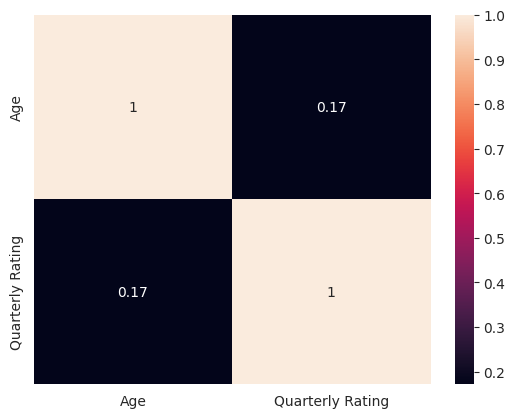

In [108]:
sns.heatmap(df_[['Age', 'Quarterly Rating']].corr(), annot=True)

##3. Name the city which showed the most improvement in Quarterly Rating over the past year.

Ans. C29 : +0.195073

In [120]:
df_['MMM-YY'] = pd.to_datetime(df_['MMM-YY'])
df_['year'] = df_['MMM-YY'].dt.year
city_year = (
    df_.groupby(['City','year'])['Quarterly Rating']
    .mean()
    .reset_index()
)
city_year = city_year.sort_values(['City','year'])

improvement = (
    city_year.groupby('City')['Quarterly Rating']
    .agg(first='first', last='last')
)

improvement['improvement'] = improvement['last'] - improvement['first']
ratings_table = city_year.pivot(index='City', columns='year', values='Quarterly Rating')

final = ratings_table.join(improvement['improvement'])

final.sort_values('improvement', ascending=False)

,2019,2020,improvement
City,,,
C29,2.065963,2.261036,0.195073
C24,2.076696,2.236364,0.159667
C15,1.910811,2.061381,0.150570
C5,1.986842,2.096591,0.109749
C8,2.014970,2.097884,0.082914
C13,2.003226,2.069498,0.066272
C1,1.944020,2.003521,0.059501
C7,1.877358,1.917526,0.040167
C26,2.115385,2.142857,0.027473


##4. Drivers with a Grade of ‘A’ are more likely to have a higher Total Business Value.(T/F)

Ans. False. If taken total business value per driver in grade A then True.

In [135]:
df_churn.groupby('Last Grade')['Total Business Value'].mean().sort_values(ascending = False)

,Total Business Value
Last Grade,
5,2.357335e+07
4,2.082520e+07
3,4.889091e+06
2,3.290683e+06
1,2.188876e+06


In [136]:
df_churn.groupby('Last Grade')['Total Business Value'].sum().sort_values(ascending = False)

,Total Business Value
Last Grade,
3,3045903730
4,2873876910
2,2813534070
1,1621957110
5,565760460


##5. If a driver's Quarterly Rating drops significantly, how does it impact their Total
Business Value in the subsequent period?

Ans. When a driver’s Quarterly Rating drops significantly, the next-period Total Business Value falls sharply.

In [139]:
# ---- 1. Convert date column ----
df_['MMM-YY'] = pd.to_datetime(df_['MMM-YY'], format='%b-%y')

# ---- 2. Sort data by driver and time ----
df_ = df_.sort_values(['Driver_ID', 'MMM-YY'])

# ---- 3. Compute rating change for each driver ----
df_['rating_change'] = (
    df_.groupby('Driver_ID')['Quarterly Rating']
    .diff()
)

# ---- 4. Get next period business value ----
df_['next_business_value'] = (
    df_.groupby('Driver_ID')['Total Business Value']
    .shift(-1)
)

# ---- 5. Define significant rating drop ----
# (example: drop >= 1 rating point)
df_['rating_drop'] = df_['rating_change'] <= -1

# ---- 6. Compare business value after rating drop vs normal ----
impact = (
    df_.groupby('rating_drop')['next_business_value']
    .mean()
)

print("Average next-period business value:")
print(impact)

# ---- 7. Calculate percentage impact ----
if True in impact.index and False in impact.index:
    pct_change = ((impact[True] - impact[False]) / impact[False]) * 100
    print(f"\nImpact of rating drop on next-period business value: {pct_change:.2f}%")

# ---- 8. show summary table ----
summary = (
    df_.groupby('rating_drop')
    .agg(
        drivers=('Driver_ID','nunique'),
        observations=('Driver_ID','count'),
        avg_next_business=('next_business_value','mean')
    )
)

print("\nSummary:")
print(summary)

Average next-period business value:
rating_drop
False    633220.080609
True     335855.773026
Name: next_business_value, dtype: float64

Impact of rating drop on next-period business value: -46.96%

Summary:
             drivers  observations  avg_next_business
rating_drop                                          
False           2381         17758      633220.080609
True             896          1346      335855.773026


##6. From Ola's perspective, which metric should be the primary focus for driver
retention?
    1. ROC AUC
    2. Precision
    3. Recall
    4. F1 Score

Ans.

For driver retention, OLA needs to predict which drivers are likely to leave (churn) so it can intervene.

- ROC AUC - Measures overall ranking ability across thresholds.
- Precision - Of drivers predicted to leave, how many actually leave.
- Recall - Of drivers who actually leave, how many did we detect.
- F1 score - Useful when both errors matter equally, but retention problems are asymmetric—missing churners is worse than sending unnecessary incentives.

Here Recall is most important.
Because Ola should prioritize identifying as many at-risk drivers as possible, even if it means some unnecessary retention actions.

##7. How does the gap in precision and recall affect Ola's relationship with its drivers and customers?


####Case 1: High Recall, Low Precision
---

    The model catches most drivers who will leave, but it also flags many drivers who were never planning to leave.

####Impact on drivers
---

- Many drivers receive retention incentives unnecessarily
- Some drivers may game the system if they realize poor performance triggers rewards
- Budget spent on incentives increases

####Impact on customers
---
- Driver supply remains stable
- Wait times and cancellations stay lower
- Overall marketplace reliability improves

This scenario is costly but safer for the platform.

####Case 2: High Precision, Low Recall
---

    The model is very accurate when it predicts churn, but it misses many drivers who will actually leave.

####Impact on drivers
---
- At-risk drivers receive no support or incentives
- Drivers leave the platform silently
- Driver churn increases

####Impact on customers
---

- Fewer drivers available
- Longer pickup times
- Higher surge pricing
- Worse customer experience

This scenario saves incentive cost but bad for company business because of bad customer satisfaction.

Here we will tune for `higher recall`, even if precision drops.

Reason: losing drivers reduces supply, which harms the entire network (long waits, cancellations, surge pricing). Spending extra on retention is often cheaper than rebuilding supply.

##8. Besides the obvious features like "Number of Rides", which lesser-discussed
features might have a strong impact on a driver's Quarterly Rating?

Ans. driver experience, platform tier, and city conditions can strongly affect ratings even if ride count is not considered.

##9. Will the driver's performance be affected by the City they operate in? (Yes/No)

Ans. Yes

##10. Analyze any seasonality in the driver's ratings. Do certain times of the year
correspond to higher or lower ratings, and why might that be?

In [141]:
# extract month
df_['month'] = df_['MMM-YY'].dt.month
df_['month_name'] = df_['MMM-YY'].dt.strftime('%b')

monthly_rating = (
    df_.groupby('month')['Quarterly Rating']
    .mean()
    .reset_index()
)

monthly_rating

,month,Quarterly Rating
0,1,1.953437
1,2,2.015836
2,3,2.088106
3,4,1.978332
4,5,1.983007
5,6,1.997326
6,7,2.036468
7,8,2.038953
8,9,2.019733
9,10,2.026333


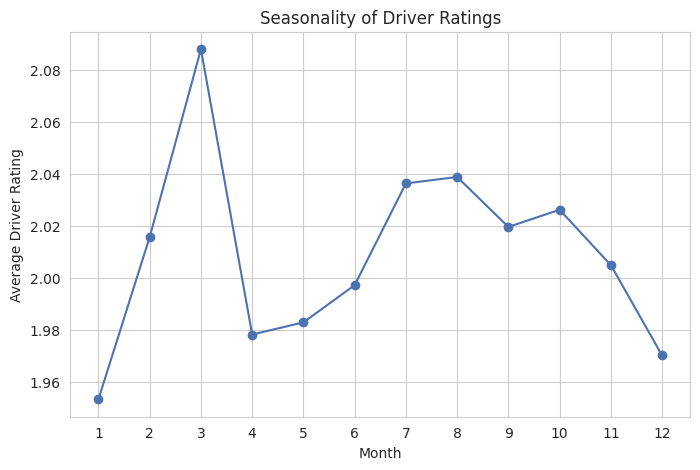

In [142]:
plt.figure(figsize=(8,5))
plt.plot(monthly_rating['month'], monthly_rating['Quarterly Rating'], marker='o')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Average Driver Rating")
plt.title("Seasonality of Driver Ratings")
plt.grid(True)
plt.show()

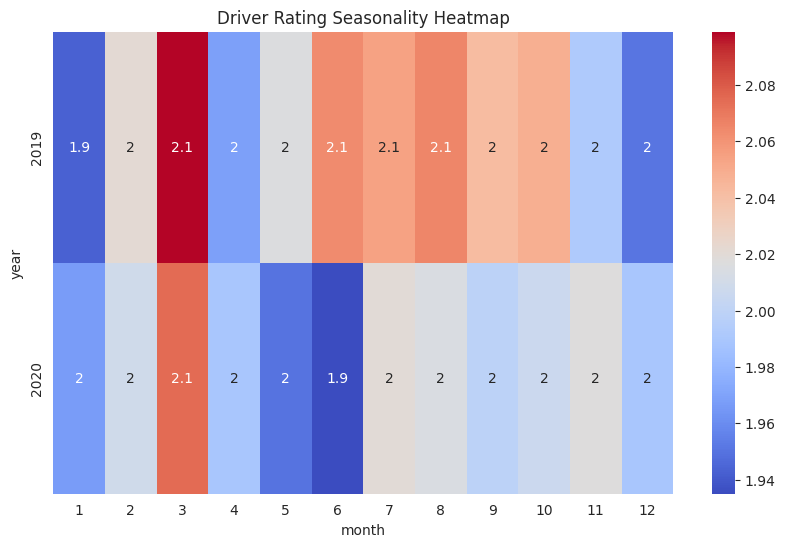

In [144]:
df_['year'] = df_['MMM-YY'].dt.year

heat = df_.pivot_table(
    values='Quarterly Rating',
    index='year',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.title("Driver Rating Seasonality Heatmap")
plt.show()

Ans. The mean rating is between 1.9 to 2.1 and it Jan to Mar there is a sharp spike and then sharp dip till april.(in Plot it look sharp but spike and dip in range 0.2)